##Notebook 2: Variables aleatorias

#San Juan Retama Juan Antonio

# Variables Aleatorias Discretas

## 1. Variable Aleatoria Uniforme Discreta

### Definición y Función de Probabilidad
Una variable aleatoria discreta $X$ tiene una **distribución uniforme discreta** sobre un conjunto finito de enteros consecutivos $\{1, 2, \dots, n\}$ si asigna exactamente la misma probabilidad a cada uno de los elementos de dicho conjunto. Se utiliza para modelar situaciones donde todos los resultados posibles son equiprobables.

**Función de Masa de Probabilidad (FMP):**
$$f_{X}(k) = \mathbb{P}(X=k) = \begin{cases} \frac{1}{n} & \text{si } k \in \{1, 2, \dots, n\} \\ 0 & \text{en otro caso} \end{cases}$$

**Notación:** $X \sim \text{Unif}(1, n)$

---

### Propiedades, Esperanza y Varianza

* **Condición de normalización:** La suma de las probabilidades sobre todo el soporte es igual a la unidad:
  $$\sum_{k=1}^n f_X(k) = \sum_{k=1}^n \frac{1}{n} = n \cdot \left(\frac{1}{n}\right) = 1$$
* **Esperanza Matemática ($\mathbb{E}[X]$):** Corresponde al punto medio del intervalo del soporte:
  $$\mathbb{E}[X] = \frac{n + 1}{2}$$
* **Varianza ($\text{Var}(X)$):** Mide la dispersión de los posibles valores respecto a su valor esperado:
  $$\text{Var}(X) = \frac{n^2 - 1}{12}$$

---

### Solución al Ejercicio de Verificación Analítica
Para demostrar formalmente las expresiones de la esperanza y la varianza, utilizaremos las siguientes identidades de sumatorias notables:
1. $\sum_{k=1}^n k = \frac{n(n+1)}{2}$
2. $\sum_{k=1}^n k^2 = \frac{n(n+1)(2n+1)}{6}$

#### Demostración de la Esperanza:
$$\mathbb{E}[X] = \sum_{k=1}^n k \cdot f_X(k) = \sum_{k=1}^n k \cdot \frac{1}{n} = \frac{1}{n} \sum_{k=1}^n k$$

Sustituyendo la primera identidad notable:
$$\mathbb{E}[X] = \frac{1}{n} \left( \frac{n(n+1)}{2} \right) = \frac{n+1}{2} \quad \blacksquare$$

#### Demostración de la Varianza:
Utilizaremos la identidad computacional de la varianza $\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$. Primero evaluamos el segundo momento $\mathbb{E}[X^2]$:
$$\mathbb{E}[X^2] = \sum_{k=1}^n k^2 \cdot \frac{1}{n} = \frac{1}{n} \sum_{k=1}^n k^2 = \frac{1}{n} \left( \frac{n(n+1)(2n+1)}{6} \right) = \frac{(n+1)(2n+1)}{6}$$

Restamos el cuadrado de la esperanza y factorizamos el término común $\frac{n+1}{2}$:
$$\text{Var}(X) = \frac{(n+1)(2n+1)}{6} - \left(\frac{n+1}{2}\right)^2$$
$$\text{Var}(X) = \frac{n+1}{2} \left[ \frac{2n+1}{3} - \frac{n+1}{2} \right] = \frac{n+1}{2} \left[ \frac{2(2n+1) - 3(n+1)}{6} \right]$$
$$\text{Var}(X) = \frac{n+1}{2} \left[ \frac{4n + 2 - 3n - 3}{6} \right] = \frac{n+1}{2} \left[ \frac{n - 1}{6} \right] = \frac{n^2 - 1}{12} \quad \blacksquare$$

---

### Ejercicio Adicional Resuelto
**Enunciado:** Encuentra la Función Generadora de Momentos (FGM) de una variable aleatoria $X \sim \text{Unif}(1, n)$ utilizando la fórmula de la suma de una serie geométrica finita.

**Solución Analítica:**
La Función Generadora de Momentos se define como $M_X(t) = \mathbb{E}[e^{tX}]$. Aplicando la definición para el caso discreto uniforme:
$$M_X(t) = \sum_{k=1}^n e^{tk} \cdot f_X(k) = \sum_{k=1}^n e^{tk} \cdot \frac{1}{n} = \frac{1}{n} \sum_{k=1}^n (e^t)^k$$

La sumatoria interior representa una serie geométrica de la forma $\sum_{k=1}^n r^k$ con razón $r = e^t$. Utilizando la fórmula de la suma geométrica finita $\sum_{k=1}^n r^k = \frac{r(1 - r^n)}{1 - r}$, obtenemos para $t \neq 0$:
$$M_X(t) = \frac{1}{n} \cdot \frac{e^t(1 - (e^t)^n)}{1 - e^t} = \frac{e^t(1 - e^{nt})}{n(1 - e^t)}$$

Para el caso en que $t = 0$, por definición del valor esperado de una constante:
$$M_X(0) = \mathbb{E}[e^{0}] = 1$$

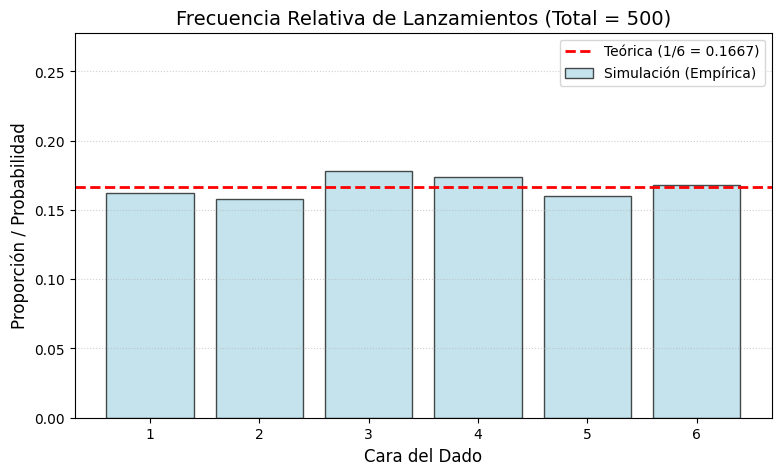

In [ ]:
import random
import matplotlib.pyplot as plt

# 1. Parámetros del experimento
n = 6                  # Caras del dado
num_lanzamientos = 500

# 2. Simulación  (generar lista de resultados)
lanzamientos = []
for i in range(num_lanzamientos):
    lanzamientos.append(random.randint(1, n))

# 3. Contar cuántas veces salió cada cara usando bucles
conteos = [0] * n  # Crea una lista de ceros: [0, 0, 0, 0, 0, 0]
for resultado in lanzamientos:
    # Restamos 1 porque los índices van de 0 a 5
    conteos[resultado - 1] += 1

# 4. Calcular la frecuencia relativa (proporción de veces que salió cada cara)
frecuencias_empiricas = []
for c in conteos:
    frecuencias_empiricas.append(c / num_lanzamientos)

# 5. Definir los valores del eje X (las caras del dado) y la probabilidad teórica
caras = [1, 2, 3, 4, 5, 6]
probabilidad_teorica = 1 / n

# 6. Crear la gráfica
plt.figure(figsize=(9, 5))

# Dibujar las barras con los resultados
plt.bar(caras, frecuencias_empiricas, color='lightblue', edgecolor='black', alpha=0.7, label='Simulación (Empírica)')

# Dibujar una línea horizontal fija que representa el valor matemático real
plt.axhline(y=probabilidad_teorica, color='red', linestyle='--', linewidth=2, label=f'Teórica (1/{n} = {probabilidad_teorica:.4f})')

# Configurar detalles estéticos del gráfico
plt.title(f'Frecuencia Relativa de Lanzamientos (Total = {num_lanzamientos})', fontsize=14)
plt.xlabel('Cara del Dado', fontsize=12)
plt.ylabel('Proporción / Probabilidad', fontsize=12)
plt.xticks(caras)
plt.ylim(0, max(frecuencias_empiricas) + 0.1)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()


plt.show()

## 2. Variable Aleatoria Bernoulli con parámetro $p\in (0,1)$

El modelo probabilístico Bernoulli se aplica a un experimento cuyo espacio muestral está constituido sólo por dos resultados posibles, éxito y fracaso:

Se considerará una v.a. $X$ sobre el espacio muestral $$\Omega=\{\text{éxito, fracaso}\}$$
de tal forma que
* $X(\{\text{éxito}\}) = 1$
* $X(\{\text{fracaso}\}) = 0$

Las probabilidades asociadas a este modelo son:
* $\mathbb{P}(\{\text{éxito}\}) = p$
* $\mathbb{P}(\{\text{fracaso}\}) = 1-p$

donde $0<p<1$.

Entonces la función de masa de probabilidades (FMP) de $X$ está dada por:
$$f_{X}(k)=\begin{cases}
p &\quad \text{si } k=1 \\
1-p &\quad \text{si } k=0 \\
0 &\quad \text{en otro caso}
\end{cases}$$

Una forma algebraica compacta de escribir esta misma función para $k \in \{0, 1\}$ es:
$$f_X(k) = p^k (1-p)^{1-k}$$

**Notación:** $X\sim \text{Ber}(p)$.

Esta variable aleatoria es muy importante. En la práctica es usada para modelar situaciones en las cuales hay dos posibles resultados como:
* El estado de un teléfono en un momento dado: libre u ocupado.
* Una persona pueda estar enferma o sana de una determinada enfermedad.
* La preferencia de una persona, la cual puede estar a favor o en contra de un candidato determinado.

Mediante la combinación de variables aleatorias Bernoulli es posible construir otras variables aleatorias (como la Binomial o la Geométrica).

---

### Propiedades, Esperanza y Varianza

* **Condición de normalización:** La suma de probabilidades sobre su soporte $\{0, 1\}$ es unitaria:
  $$\sum_{k=0}^{1} f_X(k) = f_X(0) + f_X(1) = (1-p) + p = 1$$

* **Esperanza Matemática ($\mathbb{E}[X]$):**
  $$\mathbb{E}[X] = \sum_{k=0}^{1} k \cdot f_{X}(k) = 0 \cdot (1-p) + 1 \cdot p = p$$

* **Varianza ($\text{Var}(X)$):**
  Para calcularla, primero evaluamos el segundo momento lineal $\mathbb{E}[X^{2}]$:
  $$\mathbb{E}[X^{2}] = \sum_{k=0}^{1} k^{2} \cdot f_{X}(k) = 0^{2} \cdot (1-p) + 1^{2} \cdot p = p$$
  Por lo tanto, aplicando la identidad computacional de la varianza:
  $$\text{Var}(X) = \mathbb{E}[X^{2}] - (\mathbb{E}[X])^{2} = p - p^{2} = p(1-p)$$

---

### Función Generadora de Momentos (FGM)
La FGM de una variable aleatoria Bernoulli se obtiene directamente aplicando la definición de valor esperado para transformaciones exponenciales $M_X(t) = \mathbb{E}[e^{tX}]$:
$$M_X(t) = \sum_{k=0}^1 e^{tk} \cdot f_X(k) = e^{t(0)} \cdot (1-p) + e^{t(1)} \cdot p$$
$$M_X(t) = 1 - p + p e^t \quad \forall t \in \mathbb{R}$$

#### Verificación de Momentos usando la FGM:
Podemos comprobar la Esperanza y el Segundo Momento derivando la FGM respecto a $t$ y evaluando en $t=0$:
1. **Primera derivada:** $M_X'(t) = \frac{d}{dt}(1 - p + p e^t) = p e^t$
   $$\mathbb{E}[X] = M_X'(0) = p e^0 = p$$
2. **Segunda derivada:** $M_X''(t) = \frac{d}{dt}(p e^t) = p e^t$
   $$\mathbb{E}[X^2] = M_X''(0) = p e^0 = p$$

---

### Ejercicio Adicional
**Enunciado:** Si $X \sim \text{Ber}(p)$, encuentra la expresión analítica para el momento central de orden $r$ (denotado como $\mu_r = \mathbb{E}[(X - \mathbb{E}[X])^r]$) y evalúalo específicamente para el caso de $r = 3$ (Asimetría / Skewness no estandarizada).

**Solución Analítica:**
Por definición de valor esperado discreto, expandimos la sumatoria sobre el soporte finito $\{0, 1\}$, sabiendo que $\mathbb{E}[X] = p$:
$$\mu_r = \sum_{k=0}^1 (k - p)^r \cdot f_X(k)$$
$$\mu_r = (0 - p)^r \cdot (1-p) + (1 - p)^r \cdot p$$
$$\mu_r = (-p)^r (1-p) + (1-p)^r p$$

Para el caso particular de $r = 3$:
$$\mu_3 = (-p)^3(1-p) + (1-p)^3 p = -p^3(1-p) + p(1-p)(1-p)^2$$
Factorizando el término común $p(1-p)$:
$$\mu_3 = p(1-p) \left[ -p^2 + (1 - 2p + p^2) \right]$$
$$\mu_3 = p(1-p)(1 - 2p)$$

*(Nota: Esto demuestra que si $p = 0.5$, $\mu_3 = 0$, lo cual refleja matemáticamente que la distribución es perfectamente simétrica alrededor de su media cuando ambas opciones son equiprobables).*

---

### Visualización y Simulación Algorítmica

Simulamos un proceso de Bernoulli (como lanzar una moneda sesgada donde la probabilidad de obtener "Éxito" es $p = 0.6$). Calcularemos las frecuencias de forma manual y graficaremos el comportamiento.

--- VALIDACIÓN DE MOMENTOS (Bernoulli) ---
Esperanza Teórica (p):     0.6000 | Media Empírica Muestral: 0.5970
Varianza Teórica (p*(1-p)): 0.2400 | Varianza Empírica Muestral: 0.2406


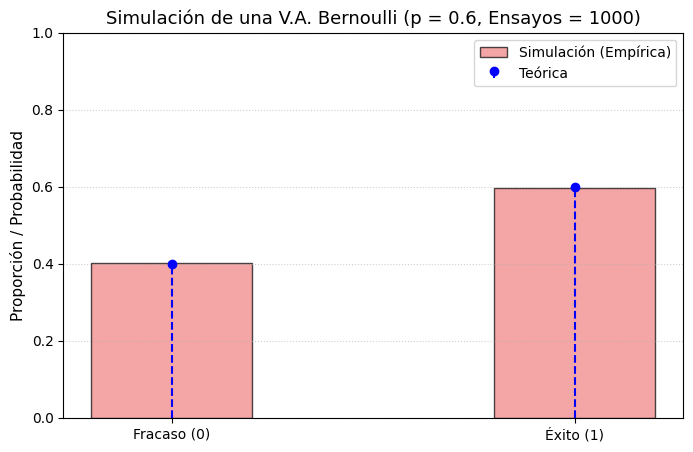

In [ ]:
import random
import matplotlib.pyplot as plt

# 1. Parámetros del experimento de Bernoulli
p = 0.6                 # Probabilidad de éxito (1)
num_ensayos = 1000      # Número de experimentos simulados

# 2. Simulación
resultados = []
for i in range(num_ensayos):
    # random.random() genera un flotante continuo entre 0.0 y 1.0
    u = random.random()
    if u < p:
        resultados.append(1)  # Éxito
    else:
        resultados.append(0)  # Fracaso

# 3. Conteo manual de frecuencias empíricas
conteo_fracasos = resultados.count(0)
conteo_exitos = resultados.count(1)

frecuencia_empirica = [conteo_fracasos / num_ensayos, conteo_exitos / num_ensayos]
categorias = ['Fracaso (0)', 'Éxito (1)']
fmp_teorica = [1 - p, p]

# 4. Construcción de la gráfica comparativa
plt.figure(figsize=(8, 5))

# Dibujar barras
plt.bar(categorias, frecuencia_empirica, color='lightcoral', edgecolor='black', width=0.4, alpha=0.7, label='Simulación (Empírica)')

# Dibujar puntos de la FMP Teórica exacta
plt.stem(categorias, fmp_teorica, linefmt='b--', markerfmt='bo', basefmt=' ', label='Teórica')

plt.title(f'Simulación de una V.A. Bernoulli (p = {p}, Ensayos = {num_ensayos})', fontsize=13)
plt.ylabel('Proporción / Probabilidad', fontsize=11)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

# Mostrar resultados
media_empirica = sum(resultados) / num_ensayos
# Varianza empírica calculada
varianza_empirica = sum((x - media_empirica)**2 for x in resultados) / num_ensayos

print("--- VALIDACIÓN DE MOMENTOS (Bernoulli) ---")
print(f"Esperanza Teórica (p):     {p:.4f} | Media Empírica Muestral: {media_empirica:.4f}")
print(f"Varianza Teórica (p*(1-p)): {p*(1-p):.4f} | Varianza Empírica Muestral: {varianza_empirica:.4f}")

plt.show()

## 3. Variable Aleatoria Binomial con parámetros $n$ y $p \in (0,1)$

### Definición y Función de Probabilidad
La distribución binomial surge naturalmente al modelar el número total de "éxitos" acumulados al realizar una serie de $n$ ensayos independientes e idénticamente distribuidos (i.i.d.) de Bernoulli, donde cada ensayo individual tiene una probabilidad fija de éxito $p$.

Decimos que una v.a. $X$ tiene distribución binomial con parámetros $n$ y $p$, si su función de masa de probabilidades (FMP) está dada por:
$$\begin{equation*}
	f_{X}(k)= \mathbb{P}(X=k)= \begin{cases}
	\binom{n}{k}p^{k}(1-p)^{n-k} &\quad \text{si } k=0,1,\dots,n \\
	0 &\quad \text{en otro caso}  
	\end{cases}
\end{equation*}$$
donde $n$ es un entero positivo (número de ensayos) y $0 < p < 1$. El coeficiente binomial se define como $\binom{n}{k} = \frac{n!}{k!(n-k)!}$.

**Notación:** $X \sim \text{Bin}(n, p)$.

---

### Propiedades, Esperanza y Varianza

* **Relación Reproductiva con Bernoulli:** Si $Y_1, Y_2, \dots, Y_n$ son variables aleatorias i.i.d. tales que $Y_i \sim \text{Ber}(p)$, entonces:
  $$X = \sum_{i=1}^n Y_i \sim \text{Bin}(n, p)$$

* **Condición de normalización:** Por el Teorema del Binomio de Newton, la suma sobre todo el soporte es unitaria:
  $$\sum_{k=0}^n \binom{n}{k}p^k(1-p)^{n-k} = (p + (1-p))^n = 1^n = 1$$

* **Esperanza Matemática ($\mathbb{E}[X]$):**
  \begin{align*}
  \mathbb{E}[X]&= \sum_{k \mathop = 0}^n k \binom n k p^k (1-p)^{n - k}\\
  &=\sum_{k \mathop = 1}^n k \binom n k p^k (1-p)^{n - k}\\
  &= \sum_{k \mathop = 1}^n n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
  &= n p \sum_{k \mathop = 1}^n \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{( {n - 1}) - ( {k - 1}) }\\
  &=n p \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} \quad (\text{donde } m = n-1 \text{ y } j = k-1)\\
  &=np
  \end{align*}

* **Varianza ($\text{Var}(X)$):**
  Primero, calculamos el segundo momento $\mathbb{E}[X^2]$ expandiendo algebraicamente mediante propiedades del coeficiente binomial:
  \begin{align*}
  \mathbb{E}[X^2]&= \sum_{k \mathop = 0}^n k^2 \binom n k p^k (1-p)^{n - k}\\
  &=\sum_{k \mathop = 0}^n k n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
  &= n p \sum_{k \mathop = 1}^n k \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{({n - 1}) - ({k - 1}) }\\
  &= n p \sum_{j \mathop = 0}^m ({j + 1}) \binom m j p^j (1-p)^{m - j}\\
  &=n p \left( {\sum_{j \mathop = 0}^m j \binom m j p^j (1-p)^{m - j} + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
  &=n p \left( {\sum_{j \mathop = 0}^m m \binom {m - 1} {j - 1} p^j (1-p)^{m - j} + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
  &= n p \left( (n - 1) p \sum_{j \mathop = 1}^m \binom {m - 1}{j - 1} p^{j - 1} (1-p)^{( {m - 1}) - ({j - 1}) } + \sum_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\right) \\
  &= n p \left( (n - 1) p (p + (1-p))^{m - 1} + (p + (1-p))^m\right)\\
  &= n p ((n - 1) p + 1)\\
  &= (np)^2 +np(1-p)
  \end{align*}
  
  Por lo tanto, la varianza final aplicando el teorema de Steiner es:
  $$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = (np)^2 + np(1-p) - (np)^2 = np(1-p)$$

---

### Función Generadora de Momentos (FGM)
Aprovechando la propiedad de independencia de los ensayos y la linealidad exponencial, deducimos la FGM $M_X(t) = \mathbb{E}[e^{tX}]$. Como $X = \sum_{i=1}^n Y_i$ donde cada $Y_i \sim \text{Ber}(p)$, entonces:
$$M_X(t) = \mathbb{E}[e^{t(Y_1 + \dots + Y_n)}] = \prod_{i=1}^n \mathbb{E}[e^{tY_i}] = \prod_{i=1}^n M_{Y_i}(t)$$

Sustituyendo la FGM ya conocida de una variable aleatoria Bernoulli:
$$M_X(t) = \prod_{i=1}^n (1 - p + p e^t) = (1 - p + p e^t)^n \quad \forall t \in \mathbb{R}$$

---

### Ejercicio Adicional
**Enunciado:** Demuestra de manera alternativa la esperanza $\mathbb{E}[X]$ de una variable $X \sim \text{Bin}(n, p)$ aplicando la primera derivada de su Función Generadora de Momentos (FGM) evaluada en $t = 0$.

**Solución Analítica:**
Tomamos la FGM deducida anteriormente $M_X(t) = (1 - p + p e^t)^n$ y aplicamos la regla de la cadena para obtener su primera derivada respecto a $t$:
$$M'_X(t) = \frac{d}{dt} \left[ (1 - p + p e^t)^n \right] = n(1 - p + p e^t)^{n-1} \cdot \frac{d}{dt}(1 - p + p e^t)$$
$$M'_X(t) = n(1 - p + p e^t)^{n-1} \cdot (p e^t)$$

Evaluamos el límite de la derivada cuando $t \to 0$:
$$\mathbb{E}[X] = M'_X(0) = n(1 - p + p e^0)^{n-1} \cdot (p e^0)$$
$$\mathbb{E}[X] = n(1 - p + p)^{n-1} \cdot (p) = n(1)^{n-1} \cdot p = np \quad \blacksquare$$

---

### Simulación
Creamos una simulacion de los $n$ ensayos de Bernoulli  para construir un único dato de la Binomial, repitiendo este proceso $N$ veces para analizar estadísticamente las aproximaciones.

--- VALIDACIÓN DE MOMENTOS (Binomial) ---
Esperanza Teórica (n*p):     4.0000 | Media Empírica Muestral: 3.9630
Varianza Teórica (n*p*(1-p)): 2.4000 | Varianza Empírica Muestral: 2.4676


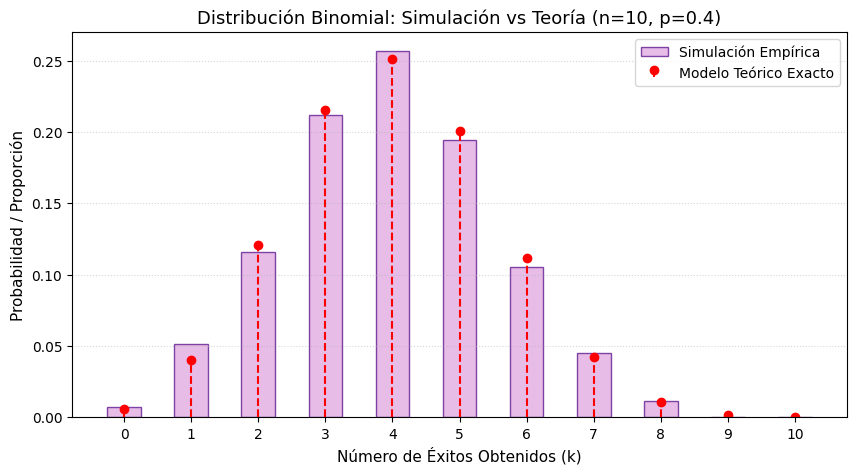

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Configuración de parámetros de la variable Binomial
n_ensayos = 10          # Número de intentos por experimento (n)
p_exito = 0.4           # Probabilidad de éxito individual (p)
num_simulaciones = 2000 # Cuántas veces repetiremos todo el proceso (N)

# 2. Simulación
datos_binomiales = []
for _ in range(num_simulaciones):
    exitos_acumulados = 0
    for _ in range(n_ensayos):
        if random.random() < p_exito:
            exitos_acumulados += 1
    datos_binomiales.append(exitos_acumulados)

# 3. Conteo para calcular las frecuencias
valores_soporte = list(range(n_ensayos + 1))
conteos = [datos_binomiales.count(k) for k in valores_soporte]
fmp_empirica = [c / num_simulaciones for c in conteos]

# 4. Cálculo de la curva Teórica
fmp_teorica = [stats.binom.pmf(k, n_ensayos, p_exito) for k in valores_soporte]


plt.figure(figsize=(10, 5))

# Graficar histograma
plt.bar(valores_soporte, fmp_empirica, color='plum', edgecolor='indigo', width=0.5, alpha=0.7, label='Simulación Empírica')

plt.stem(valores_soporte, fmp_teorica, linefmt='r--', markerfmt='ro', basefmt=' ', label='Modelo Teórico Exacto')

# Detalles estéticos de la visualización
plt.title(f'Distribución Binomial: Simulación vs Teoría (n={n_ensayos}, p={p_exito})', fontsize=13)
plt.xlabel('Número de Éxitos Obtenidos (k)', fontsize=11)
plt.ylabel('Probabilidad / Proporción', fontsize=11)
plt.xticks(valores_soporte)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend()

# 6. Cálculo numérico de momentos muestrales vs teóricos
media_emp = np.mean(datos_binomiales)
var_emp = np.var(datos_binomiales)

media_teo = n_ensayos * p_exito
var_teo = n_ensayos * p_exito * (1 - p_exito)

print("--- VALIDACIÓN DE MOMENTOS (Binomial) ---")
print(f"Esperanza Teórica (n*p):     {media_teo:.4f} | Media Empírica Muestral: {media_emp:.4f}")
print(f"Varianza Teórica (n*p*(1-p)): {var_teo:.4f} | Varianza Empírica Muestral: {var_emp:.4f}")

plt.show()



## 4. Variable Aleatoria Poisson

### Definición y Función de Probabilidad
Es una distribución de probabilidad discreta que sirve para calcular la probabilidad de que ocurra un determinado **número de eventos raros** durante un intervalo continuo dado (puede ser de tiempo, longitud, área, volumen, etc.) bajo condiciones de estabilidad y tasas de ocurrencia constantes.

Esta variable aleatoria toma valores sobre el soporte infinito contable $\{0, 1, 2, \dots\}$ y tiene un parámetro $\lambda > 0$, el cual representa la tasa media o el número de veces que se **espera** que ocurra el evento durante el intervalo analizado.

La función de masa de probabilidades (FMP) de una variable aleatoria Poisson, $X$, está dada por:
$$f_{X}(k)=\begin{cases}
  e^{-\lambda}\frac{\lambda^{k}}{k!} &\quad \text{si } k=0,1,2,\dots \\
  0 &\quad \text{en otro caso}  
\end{cases}$$

**Notación:** $X \sim \text{Poi}(\lambda)$

En efecto, es una función de masa de probabilidades legítima debido a que cumple la condición de normalización:
$$\begin{align*}
\sum_{k=0}^{\infty}e^{-\lambda}\frac{\lambda^{k}}{k!} &= e^{-\lambda}\sum_{k=0}^{\infty}\frac{\lambda^{k}}{k!} \\
&= e^{-\lambda}\underbrace{\left(1+\lambda+\frac{\lambda^{2}}{2!}+\frac{\lambda^{3}}{3!}+\cdots\right)}_{\text{desarrollo de Taylor de }e^{\lambda}} \\
&= e^{-\lambda}e^{\lambda}=1 \quad \blacksquare
\end{align*}$$

---

### Demostración Analítica de la Esperanza y la Varianza

#### 1. Esperanza Matemática ($\mathbb{E}[X] = \lambda$):
Por definición de valor esperado para el caso discreto:
$$\mathbb{E}[X] = \sum_{k=0}^{\infty} k \cdot e^{-\lambda}\frac{\lambda^{k}}{k!}$$
Como el término para $k=0$ se anula, podemos iniciar la sumatoria en $k=1$ y simplificar $k/k! = 1/(k-1)!$:
$$\mathbb{E}[X] = \sum_{k=1}^{\infty} k \cdot e^{-\lambda}\frac{\lambda^{k}}{k!} = e^{-\lambda} \sum_{k=1}^{\infty} \frac{\lambda^{k}}{(k-1)!}$$
Factorizamos un parámetro $\lambda$:
$$\mathbb{E}[X] = \lambda e^{-\lambda} \sum_{k=1}^{\infty} \frac{\lambda^{k-1}}{(k-1)!}$$
Haciendo un cambio de variable en el índice ($j = k - 1$):
$$\mathbb{E}[X] = \lambda e^{-\lambda} \underbrace{\sum_{j=0}^{\infty} \frac{\lambda^{j}}{j!}}_{e^{\lambda}} = \lambda e^{-\lambda} e^{\lambda} = \lambda \quad \blacksquare$$

#### 2. Varianza ($\text{Var}(X) = \lambda$):
Para calcular el segundo momento $\mathbb{E}[X^2]$, es matemáticamente más conveniente evaluar primero el momento factorial de segundo orden $\mathbb{E}[X(X-1)]$:
$$\mathbb{E}[X(X-1)] = \sum_{k=0}^{\infty} k(k-1) \cdot e^{-\lambda}\frac{\lambda^{k}}{k!}$$
Los términos $k=0$ y $k=1$ se anulan. Comenzamos en $k=2$ y cancelamos algebraicamente $k(k-1)/k! = 1/(k-2)!$:
$$\mathbb{E}[X(X-1)] = e^{-\lambda} \sum_{k=2}^{\infty} \frac{\lambda^k}{(k-2)!} = \lambda^2 e^{-\lambda} \sum_{k=2}^{\infty} \frac{\lambda^{k-2}}{(k-2)!}$$
Aplicando el cambio de variable $j = k-2$:
$$\mathbb{E}[X(X-1)] = \lambda^2 e^{-\lambda} \underbrace{\sum_{j=0}^{\infty} \frac{\lambda^j}{j!}}_{e^{\lambda}} = \lambda^2 e^{-\lambda} e^{\lambda} = \lambda^2$$
Por linealidad del valor esperado sabemos que $\mathbb{E}[X(X-1)] = \mathbb{E}[X^2] - \mathbb{E}[X]$, de donde despejamos el segundo momento lineal:
$$\mathbb{E}[X^2] = \mathbb{E}[X(X-1)] + \mathbb{E}[X] = \lambda^2 + \lambda$$
Finalmente, utilizando la identidad de la varianza:
$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = (\lambda^2 + \lambda) - \lambda^2 = \lambda \quad \blacksquare$$

---

### Función Generadora de Momentos (FGM)
Determinamos la FGM aplicando la definición $M_X(t) = \mathbb{E}[e^{tX}]$ para variables discretas:
$$M_X(t) = \sum_{k=0}^{\infty} e^{tk} \cdot e^{-\lambda}\frac{\lambda^{k}}{k!} = e^{-\lambda} \sum_{k=0}^{\infty} \frac{( \lambda e^t )^k}{k!}$$
La sumatoria resultante corresponde exactamente a la serie de Taylor para $e^{\lambda e^t}$. Por lo tanto:
$$M_X(t) = e^{-\lambda} \cdot e^{\lambda e^t} = e^{\lambda(e^t - 1)} \quad \forall t \in \mathbb{R}$$

---

### Ejercicio Adicional
**Enunciado:** Supongamos que el número de fallas semanales en una línea de producción de alta tecnología se modela mediante una variable aleatoria de Poisson con tasa $\lambda = 2.5$ fallas/semana. Calcule analíticamente:
1. La probabilidad exacta de que ocurran menos de 2 fallas en una semana dada.
2. Si las semanas son independientes, la probabilidad de que en un mes (definido como 4 semanas) ocurran exactamente 8 fallas en total.

**Solución Analítica:**
1. "Menos de 2 fallas" equivale algebraicamente a $\mathbb{P}(X < 2) = \mathbb{P}(X = 0) + \mathbb{P}(X = 1)$. Evaluamos con $\lambda = 2.5$:
   $$\mathbb{P}(X = 0) = e^{-2.5} \frac{2.5^0}{0!} = e^{-2.5} \approx 0.0821$$
   $$\mathbb{P}(X = 1) = e^{-2.5} \frac{2.5^1}{1!} = 2.5 e^{-2.5} \approx 0.2052$$
   $$\mathbb{P}(X < 2) = 0.0821 + 0.2052 = 0.2873 \quad (28.73\%)$$

2. Por la propiedad aditiva de la distribución de Poisson, si $X_1, X_2, X_3, X_4$ son variables i.i.d. con $X_i \sim \text{Poi}(\lambda)$, la variable aleatoria total $Y = \sum_{i=1}^4 X_i$ se distribuye como una Poisson con un nuevo parámetro $\lambda_{total} = 4 \cdot \lambda$:
   $$\lambda_{total} = 4 \times 2.5 = 10 \text{ fallas al mes}$$
   Calculamos ahora la probabilidad exacta para $k = 8$:
   $$\mathbb{P}(Y = 8) = e^{-10} \frac{10^8}{8!} = e^{-10} \frac{100,000,000}{40,320} \approx 0.1126 \quad (11.26\%)$$

---

### Simulación
Usando la  aproximación asintótica de la distribución Binomial cuando $n \to \infty$ y $p \to 0$ manteniendo $np = \lambda$.

Tomaremos un $n$ grande (pasos de tiempo muy pequeños) para construir cada simulación.

<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:54: SyntaxWarning: invalid escape sequence '\l'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:53: SyntaxWarning: invalid escape sequence '\l'
<>:54: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_4948/2948350587.py:41: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Distribución de Poisson: Simulación vs Teoría ($\lambda$ = {lambda_tasa})', fontsize=13)
/tmp/ipykernel_4948/2948350587.py:53: SyntaxWarning: invalid escape sequence '\l'
  print(f"Esperanza Teórica ($\lambda$): {lambda_tasa:.4f} | Media Empírica Muestral: {media_emp:.4f}")
/tmp/ipykernel_4948/2948350587.py:54: SyntaxWarning: invalid escape sequence '\l'
  print(f"Varianza Teórica ($\lambda$):  {lambda_tasa:.4f} | Varianza Empírica Muestral: {var_emp:.4f}")


--- VALIDACIÓN DE MOMENTOS (Poisson) ---
Esperanza Teórica ($\lambda$): 3.0000 | Media Empírica Muestral: 3.0030
Varianza Teórica ($\lambda$):  3.0000 | Varianza Empírica Muestral: 2.9230


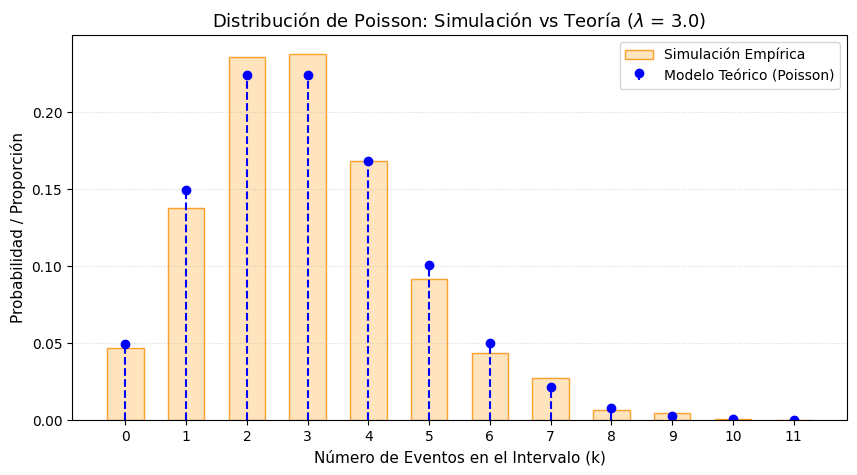

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Configuración de parámetros
lambda_tasa = 3.0       # Tasa promedio de eventos (lambda)
num_simulaciones = 2000 # Muestras empíricas a generar (N)

# 2. Simulación mediante la aproximación Binomial (n grande, p chico)
# Modelamos el intervalo continuo dividiéndolo en n subintervalos muy pequeños
n_subintervalos = 500
p_evento = lambda_tasa / n_subintervalos

datos_poisson = []
for _ in range(num_simulaciones):
    eventos_contados = 0
    for _ in range(n_subintervalos):
        if random.random() < p_evento:
            eventos_contados += 1
    datos_poisson.append(eventos_contados)

# 3. Procesamiento de frecuencias
max_valor = max(datos_poisson) + 2
valores_soporte = list(range(max_valor))
conteos = [datos_poisson.count(k) for k in valores_soporte]
fmp_empirica = [c / num_simulaciones for c in conteos]

# 4. Distribución Teórica  usando la fórmula exacta de Poisson
fmp_teorica = [stats.poisson.pmf(k, lambda_tasa) for k in valores_soporte]

# 5. Gráfica
plt.figure(figsize=(10, 5))

# Dibujar barras
plt.bar(valores_soporte, fmp_empirica, color='navajowhite', edgecolor='darkorange', width=0.6, alpha=0.8, label='Simulación Empírica')


plt.stem(valores_soporte, fmp_teorica, linefmt='b--', markerfmt='bo', basefmt=' ', label='Modelo Teórico (Poisson)')

plt.title(f'Distribución de Poisson: Simulación vs Teoría ($\lambda$ = {lambda_tasa})', fontsize=13)
plt.xlabel('Número de Eventos en el Intervalo (k)', fontsize=11)
plt.ylabel('Probabilidad / Proporción', fontsize=11)
plt.xticks(valores_soporte)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend()

# 6. Cálculo numérico de momentos muestrales vs teóricos
media_emp = np.mean(datos_poisson)
var_emp = np.var(datos_poisson)

print("--- VALIDACIÓN DE MOMENTOS (Poisson) ---")
print(f"Esperanza Teórica ($\lambda$): {lambda_tasa:.4f} | Media Empírica Muestral: {media_emp:.4f}")
print(f"Varianza Teórica ($\lambda$):  {lambda_tasa:.4f} | Varianza Empírica Muestral: {var_emp:.4f}")

plt.show()

## 5. Variable Aleatoria Geométrica

### Definición y Función de Probabilidad
Esta variable aleatoria modela un proceso de ensayos independientes e idénticamente distribuidos de Bernoulli (cada uno con probabilidad de éxito $p$). Existen dos definiciones clásicas en la literatura según el enfoque del soporte:
1. **Número total de ensayos necesarios hasta el primer éxito ($k \in \{1, 2, \dots\}$).** Es la formulación que usaremos como base.
2. **Número de fracasos acumulados antes del primer éxito ($k \in \{0, 1, \dots\}$).**

Para nuestro caso base, la función de masa de probabilidades (FMP) de $X$ está dada por:
$$f_{X}(k)=\begin{cases}
  p(1-p)^{k-1} &\quad \text{si } k=1,2,\dots \\
  0 &\quad \text{en otro caso}  
\end{cases}$$

**Notación:** $X\sim \text{Geo}(p)$.

Es una función de distribución de probabilidad legítima debido a que cumple la condición de normalización:
* $0\le f_{X}(k)\le 1$ para toda $k$.
* $$\begin{align*}
  \sum_{k=1}^{\infty}f_{X}(k) &= \sum_{k=1}^{\infty}p(1-p)^{k-1} \\
      &= p\sum_{y=0}^{\infty}(1-p)^{y} \quad (\text{haciendo } y = k-1) \\
      &= p\left(\frac{1}{1-(1-p)}\right) = p\left(\frac{1}{p}\right) = 1 \quad \blacksquare
    \end{align*}$$

---

### Propiedad Destacada: Falta de Memoria (Amnesia)
La distribución geométrica es la única distribución discreta que no tiene memoria. Esto significa que la probabilidad de que se requieran más de $s+t$ ensayos, dado que ya se han realizado $s$ ensayos sin éxito, depende únicamente del tiempo adicional $t$:
$$\mathbb{P}(X > s+t \mid X > s) = \mathbb{P}(X > t) \quad \forall s, t \in \{1, 2, \dots\}$$

---

### Esperanza y Varianza Analítica
Para deducir los momentos de $X$, establecemos formalmente el siguiente lema basado en la convergencia de series geométricas:

**Lema 1:** Sea $x$ un número real tal que $|x|<1$. Entonces,
$$\sum_{k=1}^{\infty}kx^{k-1}=\frac{1}{(1-x)^2}$$
**Demostración:**
$$\frac{d}{dx}\sum_{k=1}^{\infty}x^{k}=\sum_{k=1}^{\infty}kx^{k-1}$$
Sabiendo que la serie infinita converge a $\sum_{k=1}^{\infty}x^{k}=\frac{x}{1-x}$, aplicamos la regla del cociente para su derivada:
$$\frac{d}{dx}\left(\frac{x}{1-x}\right)=\frac{1(1-x) - x(-1)}{(1-x)^2} = \frac{1}{(1-x)^2} \quad \blacksquare$$

**Corolario 1:** De igual forma, derivando por segunda vez se obtiene la relación factorial:
$$\sum_{k=1}^{\infty}k(k+1)x^{k-1}=\frac{2}{(1-x)^3}$$

#### 1. Esperanza Matemática ($\mathbb{E}[X]$):
\begin{align*}
\mathbb{E}[X]&=  \sum_{k \ge 1} k \cdot p(1-p)^{k - 1}\\
&= p \left( \frac{1}{(1 - (1-p))^2} \right) \quad (\text{Aplicando Lema 1 con } x = 1-p)\\
&=  \frac{p}{p^2} = \frac{1}{p} \quad \blacksquare
\end{align*}

#### 2. Varianza ($\text{Var}(X)$):
Calculamos el segundo momento lineal $\mathbb{E}[X^2]$ reescribiendo algebraicamente el término cuadrático:
\begin{align*}
\mathbb{E}[X^2]&= \sum_{k=1}^{\infty} k^{2}p(1-p)^{k-1}\\
&=\sum_{k=1}^{\infty}k(k+1)p(1-p)^{k-1} - \sum_{k=1}^{\infty}kp(1-p)^{k-1}
\end{align*}
Utilizando las igualdades del Corolario 1 y del Lema 1 con $x = 1-p$:
$$\mathbb{E}[X^2]=p\left(\frac{2}{p^3}\right) - \frac{1}{p}=\frac{2}{p^2}-\frac{1}{p}$$
Por lo tanto, la varianza es:
$$\text{Var}(X)=\mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \left(\frac{2}{p^2}-\frac{1}{p}\right) - \left(\frac{1}{p}\right)^2 = \frac{1}{p^2} - \frac{1}{p} = \frac{1-p}{p^2} \quad \blacksquare$$

---

### Función Generadora de Momentos (FGM)
Determinamos la expresión para $M_X(t) = \mathbb{E}[e^{tX}]$ bajo la condición de convergencia $e^t(1-p) < 1$:
$$M_X(t) = \sum_{k=1}^{\infty} e^{tk} \cdot p(1-p)^{k-1} = p e^t \sum_{k=1}^{\infty} \left[e^t(1-p)\right]^{k-1}$$
Haciendo cambio de índice en la serie geométrica infinitamente decreciente:
$$M_X(t) = \frac{p e^t}{1 - (1-p)e^t} \quad \text{para } t < -\ln(1-p)$$

---

### Ejercicio Adicional
**Enunciado:** Demuestra analíticamente la propiedad de la función de distribución acumulada (FDA) de una variable aleatoria $X \sim \text{Geo}(p)$, específicamente demostrando que $\mathbb{P}(X > k) = (1-p)^k$.

**Solución Analítica:**
El evento $X > k$ significa geométricamente que los primeros $k$ ensayos independientes resultaron en un fracaso absoluto. Matemáticamente se expresa como:
$$\mathbb{P}(X > k) = \sum_{m=k+1}^{\infty} p(1-p)^{m-1}$$
Factorizamos el término $(1-p)^k$ fuera de la sumatoria:
$$\mathbb{P}(X > k) = p(1-p)^k \sum_{m=k+1}^{\infty} (1-p)^{m-1-k}$$
Hacemos un cambio de variable en el índice fijando $j = m - 1 - k$. Cuando $m = k+1$, el nuevo índice arranca en $j = 0$:
$$\mathbb{P}(X > k) = p(1-p)^k \sum_{j=0}^{\infty} (1-p)^j$$
La suma infinita es la serie geométrica estándar que equivale a $1/p$:
$$\mathbb{P}(X > k) = p(1-p)^k \cdot \left(\frac{1}{p}\right) = (1-p)^k \quad \blacksquare$$

---

### Simulación
Simularemos el  utilizando un ciclo `while` para lanzar "monedas" hasta que aparezca el primer éxito, analizando la cantidad total de intentos requeridos.

--- VALIDACIÓN DE MOMENTOS (Geométrica) ---
Esperanza Teórica (1/p):      2.8571 | Media Empírica Muestral: 2.8763
Varianza Teórica ((1-p)/p²):  5.3061 | Varianza Empírica Muestral: 5.3997


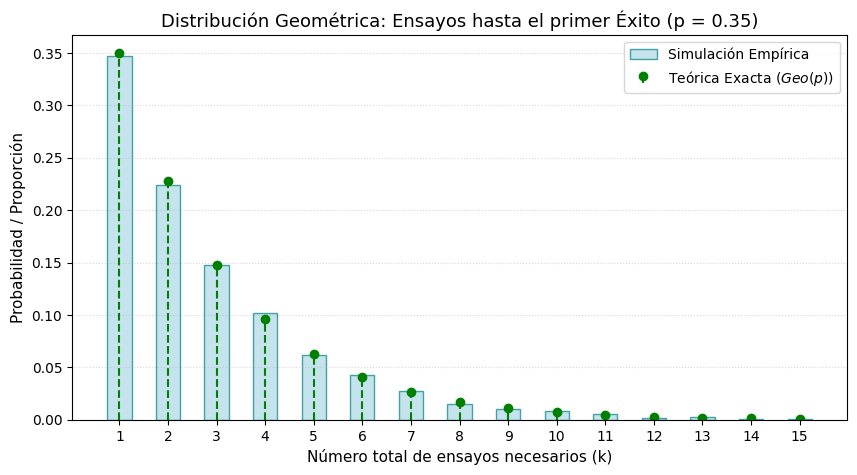

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Parámetros de la distribución Geométrica
p_exito = 0.35          # Probabilidad de éxito en cada ensayo independiente (p)
num_simulaciones = 3000 # Cantidad de experimentos individuales (N)

# 2. Simulación
datos_geometricos = []
for _ in range(num_simulaciones):
    intentos = 1
    # Bucle hasta que se cumpla la condición de éxito
    while True:
        if random.random() < p_exito:
            break # Éxito encontrado, salimos del bucle
        intentos += 1
    datos_geometricos.append(intentos)

# 3.  frecuencias
max_soporte = min(max(datos_geometricos), 15) # Truncamos visualmente en 15
valores_soporte = list(range(1, max_soporte + 1))
conteos = [datos_geometricos.count(k) for k in valores_soporte]
fmp_empirica = [c / num_simulaciones for c in conteos]

# 4. Cálculo del modelo teórico real
fmp_teorica = [stats.geom.pmf(k, p_exito) for k in valores_soporte]

# 5.Gráficos
plt.figure(figsize=(10, 5))

# Histograma
plt.bar(valores_soporte, fmp_empirica, color='lightblue', edgecolor='teal', width=0.5, alpha=0.7, label='Simulación Empírica')

# Curva teórica discreta
plt.stem(valores_soporte, fmp_teorica, linefmt='g--', markerfmt='go', basefmt=' ', label='Teórica Exacta ($Geo(p)$)')


plt.title(f'Distribución Geométrica: Ensayos hasta el primer Éxito (p = {p_exito})', fontsize=13)
plt.xlabel('Número total de ensayos necesarios (k)', fontsize=11)
plt.ylabel('Probabilidad / Proporción', fontsize=11)
plt.xticks(valores_soporte)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend()

# 6. Validación matemática
media_emp = np.mean(datos_geometricos)
var_emp = np.var(datos_geometricos)

media_teo = 1 / p_exito
var_teo = (1 - p_exito) / (p_exito**2)

print("--- VALIDACIÓN DE MOMENTOS (Geométrica) ---")
print(f"Esperanza Teórica (1/p):      {media_teo:.4f} | Media Empírica Muestral: {media_emp:.4f}")
print(f"Varianza Teórica ((1-p)/p²):  {var_teo:.4f} | Varianza Empírica Muestral: {var_emp:.4f}")

plt.show()

## Variable Aleatoria Binomial Negativa: $X \sim \text{BN}(r, p)$

La distribución **Binomial Negativa** describe procesos donde el número de éxitos deseados está predeterminado ($r$), y la incertidumbre recae sobre cuántos ensayos totales ($X$) necesitaremos realizar para alcanzar dicha meta.

### 1. Definición Formal
Supongamos que se realizan ensayos independientes de Bernoulli, cada uno con probabilidad constante de éxito $0 < p < 1$, hasta obtener un total de $r$ éxitos acumulados. Sea $X$ el número total de ensayos requeridos, su **Función de Masa de Probabilidad (PMF)** está dada por:

$$f_{X}(k) = \mathbb{P}(X = k) = \binom{k-1}{r-1} p^r (1-p)^{k-r}, \qquad \text{para } k \in \{r, r+1, r+2, \dots\}$$

**Parámetros:**
* **$r \ge 1$ (Forma):** Número de éxitos acumulados objetivo.
* **$0 < p < 1$ (Intensidad):** Probabilidad de éxito en cada ensayo independiente.

---

### 2. Propiedades Matemáticas

* **Esperanza (Media):** El número promedio esperado de ensayos totales para conseguir $r$ éxitos es:
  $$\mathbb{E}[X] = \frac{r}{p}$$

* **Varianza:** Mide la dispersión en la cantidad de ensayos necesarios:
  $$\text{Var}[X] = \frac{r(1-p)}{p^2}$$

---

### 3. Aplicaciones en Ciencia de Datos y Estadística

1. **Control de Calidad:** Determinar cuántas piezas totales inspeccionar hasta encontrar $r$ artículos defectuosos.
2. **Estrategias de Ventas:** Calcular cuántas llamadas telefónicas de prospección se necesitan realizar para cerrar $r$ ventas.
3. **Epidemiología:** Estimar la cantidad de pruebas/contactos analizados antes de detectar $r$ casos positivos.
4. **Modelado de Sobredispersión:** Alternativa superior a la distribución de Poisson cuando la varianza empírica de los datos excede significativamente a la media ($\text{Var}[X] > \mathbb{E}[X]$).
5. **Tiempos de Espera Discretos:** Predicción del tamaño muestral necesario para alcanzar una cuota de encuestas o registros válidos.

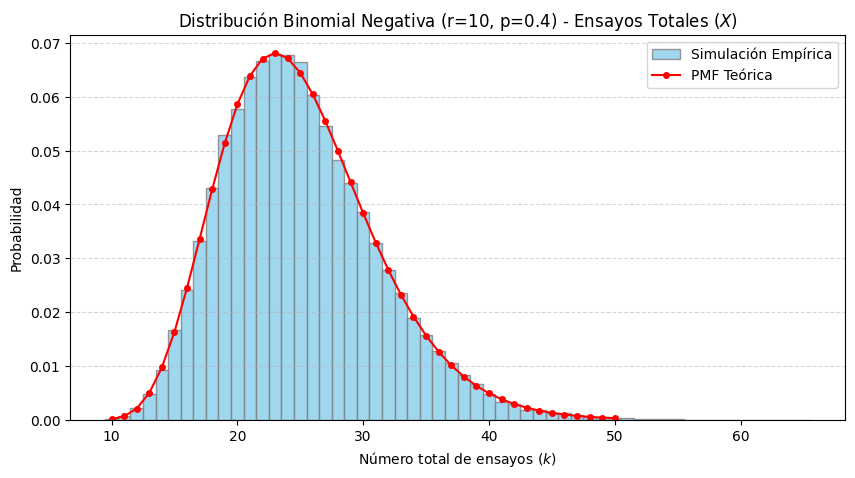

--- Comparación Numérica ---
Media Teórica:   25.0000  |  Media Empírica:   25.0123
Varianza Teórica:37.5000  |  Varianza Empírica:37.6108


In [ ]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

# Parámetros del modelo
r = 10      # Número de éxitos deseados
p = 0.4     # Probabilidad de éxito en cada ensayo
s = 100000  # Tamaño de la muestra simulada

# Fijar semilla para reproducibilidad
np.random.seed(42)

# 1. Simulación con SciPy (scipy simula número de FRACASOS)
fracasos_simulados = sps.nbinom.rvs(r, p, size=s)
ensayos_totales = fracasos_simulados + r  # Transformación a Ensayos Totales (k = fracasos + r)

# 2. Configuración de la figura
plt.figure(figsize=(10, 5))

# Histograma de la simulación empírica
plt.hist(
    ensayos_totales,
    density=True,
    bins=np.arange(r - 0.5, np.max(ensayos_totales) + 1.5, 1),
    color="skyblue",
    edgecolor="grey",
    alpha=0.8,
    label='Simulación Empírica'
)

# 3. Superposición de la PMF Teórica
x_teorico = np.arange(r, np.quantile(ensayos_totales, 0.999) + 1, dtype=int)
pmf_teorica = sps.nbinom.pmf(x_teorico - r, r, p)

plt.plot(x_teorico, pmf_teorica, 'ro-', markersize=4, linewidth=1.5, label='PMF Teórica')

# Formato visual
plt.title(f'Distribución Binomial Negativa (r={r}, p={p}) - Ensayos Totales ($X$)', fontsize=12)
plt.xlabel('Número total de ensayos ($k$)', fontsize=10)
plt.ylabel('Probabilidad', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Validaciones numéricas (Empírico vs Teórico)
media_teorica = r / p
var_teorica = (r * (1 - p)) / (p ** 2)

print(f"--- Comparación Numérica ---")
print(f"Media Teórica:   {media_teorica:.4f}  |  Media Empírica:   {np.mean(ensayos_totales):.4f}")
print(f"Varianza Teórica:{var_teorica:.4f}  |  Varianza Empírica:{np.var(ensayos_totales):.4f}")

## 7. Variable Aleatoria Hipergeométrica

### Definición y Función de Probabilidad
La distribución hipergeométrica modela el número de "éxitos" obtenidos en una muestra aleatoria de tamaño $n$ extraída **sin reemplazo** de una población finita de tamaño $N$, de la cual exactamente $K$ elementos poseen la característica deseada ("éxitos en la población").

Dado que el muestreo es sin reemplazo, las extracciones individuales **no son independientes** y la probabilidad de éxito cambia en cada intento.

**Función de Masa de Probabilidad (FMP):**
$$f_{X}(k) = \mathbb{P}(X = k) = \frac{\binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}}$$

**Soporte de la Variable ($R_X$):**
El valor de $k$ (número de éxitos en la muestra) debe satisfacer los límites físicos de la población y de la muestra:
$$k \in \{\max(0, n - (N - K)), \dots, \min(n, K)\}$$

**Notación:** $X \sim \text{Hiper}(N, K, n)$
* $N$: Tamaño total de la población ($N \in \{1, 2, \dots\}$).
* $K$: Número de éxitos en la población ($0 \le K \le N$).
* $n$: Tamaño de la muestra extraída ($1 \le n \le N$).

---

### Propiedades, Esperanza y Varianza

* **Condición de Normalización:** Aplicando la *Identidad de Vandermonde* ($\sum_k \binom{K}{k}\binom{N-K}{n-k} = \binom{N}{n}$), la suma de las probabilidades es unitaria:
  $$\sum_k f_X(k) = \frac{\sum_k \binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}} = \frac{\binom{N}{n}}{\binom{N}{n}} = 1 \quad \blacksquare$$

* **Esperanza Matemática ($\mathbb{E}[X]$):**
  Definiendo $p = \frac{K}{N}$ como la proporción de éxitos en la población inicial:
  $$\mathbb{E}[X] = n \left(\frac{K}{N}\right) = np$$

* **Varianza ($\text{Var}(X)$):**
  $$\text{Var}(X) = n \left(\frac{K}{N}\right) \left(1 - \frac{K}{N}\right) \left(\frac{N - n}{N - 1}\right) = np(1-p)\left(\frac{N - n}{N - 1}\right)$$
  *(Nota el factor $\frac{N - n}{N - 1}$, conocido como el **Factor de Corrección por Población Finita**).*

---

### Demostración Analítica de la Esperanza
Aprovechamos la propiedad binomial $k \binom{K}{k} = K \binom{K-1}{k-1}$:

$$\mathbb{E}[X] = \sum_{k=1}^n k \cdot \frac{\binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}} = \sum_{k=1}^n \frac{K \binom{K-1}{k-1} \binom{N-K}{n-k}}{\frac{N}{n} \binom{N-1}{n-1}}$$

Factorizamos la constante $\frac{n K}{N}$ fuera de la sumatoria:

$$\mathbb{E}[X] = \frac{n K}{N} \sum_{k=1}^n \frac{\binom{K-1}{k-1} \binom{(N-1)-(K-1)}{(n-1)-(k-1)}}{\binom{N-1}{n-1}}$$

Haciendo cambio de índice $j = k - 1$:

$$\mathbb{E}[X] = \frac{n K}{N} \underbrace{\sum_{j=0}^{n-1} \frac{\binom{K-1}{j} \binom{(N-1)-(K-1)}{(n-1)-j}}{\binom{N-1}{n-1}}}_{= 1 \text{ (FMP de Hiper}(N-1, K-1, n-1))} = \frac{n K}{N} \quad \blacksquare$$

---

### Ejercicio Adicional Resuelto
**Enunciado:** Un lote de $N = 20$ tarjetas madre contiene $K = 5$ unidades defectuosas. Se seleccionan $n = 4$ tarjetas al azar **sin reemplazo** para inspección.

1. Calcula la probabilidad de encontrar exactamente 2 tarjetas defectuosas en la muestra.
2. Determina el valor esperado y la varianza de tarjetas defectuosas encontradas.

**Solución Analítica:**
1. Evaluando la FMP para $k = 2$, con $N=20$, $K=5$, $n=4$:
   $$\mathbb{P}(X = 2) = \frac{\binom{5}{2} \binom{20-5}{4-2}}{\binom{20}{4}} = \frac{\binom{5}{2} \binom{15}{2}}{\binom{20}{4}}$$
   * $\binom{5}{2} = 10$
   * $\binom{15}{2} = 105$
   * $\binom{20}{4} = 4845$

   $$\mathbb{P}(X = 2) = \frac{10 \times 105}{4845} = \frac{1050}{4845} \approx 0.2167 \quad (21.67\%)$$

2. Momentos de la distribución:
   * **Esperanza:** $\mathbb{E}[X] = 4 \times \left(\frac{5}{20}\right) = 4 \times 0.25 = 1 \text{ tarjeta defectuosa.}$
   * **Varianza:** $\text{Var}(X) = 4 \times (0.25) \times (0.75) \times \left(\frac{20 - 4}{20 - 1}\right) = 1 \times 0.75 \times \left(\frac{16}{19}\right) \approx 0.6316$

---

### Simulación Algorítmica y Visualización en Python
Para la simulacion del experimento físico, construiremos una lista (población) con elementos `1` (éxito) y `0` (fracaso), utilizando `random.sample` para extraer elementos **sin reemplazo**.

--- VALIDACIÓN DE MOMENTOS (Hipergeométrica) ---
Esperanza Teórica (n*K/N): 1.0000 | Media Empírica Muestral: 0.9994
Varianza Teórica:         0.6316 | Varianza Empírica Muestral: 0.6310


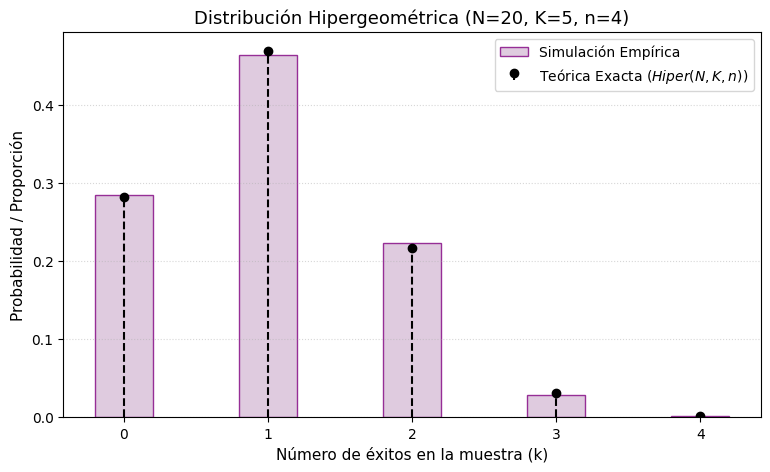

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Parámetros del experimento Hipergeométrico
N = 20                  # Población total
K = 5                   # Éxitos totales en la población
n = 4                   # Muestra extraída (sin reemplazo)
num_simulaciones = 5000 # Número de repeticiones de la simulación

# 2. Creación de la población real (1s y 0s)
poblacion = [1] * K + [0] * (N - K)

# 3. Simulación Algorítmica (Muestreo sin reemplazo usando Python puro)
datos_hiper = []
for _ in range(num_simulaciones):
    # random.sample selecciona 'n' elementos SIN REEMPLAZO de la lista
    muestra = random.sample(poblacion, n)
    exitos_en_muestra = sum(muestra)
    datos_hiper.append(exitos_en_muestra)

# 4. Procesamiento de frecuencias empíricas
soporte_min = max(0, n - (N - K))
soporte_max = min(n, K)
valores_soporte = list(range(soporte_min, soporte_max + 1))

conteos = [datos_hiper.count(k) for k in valores_soporte]
fmp_empirica = [c / num_simulaciones for c in conteos]

# 5. Cálculo Teórico Exacto con SciPy
fmp_teorica = [stats.hypergeom.pmf(k, N, K, n) for k in valores_soporte]

# 6. Gráficas Comparativas
plt.figure(figsize=(9, 5))

# Barras de la simulación empírica
plt.bar(valores_soporte, fmp_empirica, color='thistle', edgecolor='purple', width=0.4, alpha=0.8, label='Simulación Empírica')

# Stem plot del modelo teórico
plt.stem(valores_soporte, fmp_teorica, linefmt='k--', markerfmt='ko', basefmt=' ', label='Teórica Exacta ($Hiper(N,K,n)$)')

plt.title(f'Distribución Hipergeométrica (N={N}, K={K}, n={n})', fontsize=13)
plt.xlabel('Número de éxitos en la muestra (k)', fontsize=11)
plt.ylabel('Probabilidad / Proporción', fontsize=11)
plt.xticks(valores_soporte)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend()

# 7. Validación de Momentos Muestrales vs Teóricos
media_emp = np.mean(datos_hiper)
var_emp = np.var(datos_hiper)

p = K / N
media_teo = n * p
var_teo = n * p * (1 - p) * ((N - n) / (N - 1))

print("--- VALIDACIÓN DE MOMENTOS (Hipergeométrica) ---")
print(f"Esperanza Teórica (n*K/N): {media_teo:.4f} | Media Empírica Muestral: {media_emp:.4f}")
print(f"Varianza Teórica:         {var_teo:.4f} | Varianza Empírica Muestral: {var_emp:.4f}")

plt.show()

## 1. Variable Aleatoria Uniforme Continua

### Definición y Función de Densidad
Una variable aleatoria continua $X$ sigue una **distribución uniforme continua** en el intervalo cerrado $[a, b]$ (con $a < b$) si su probabilidad se distribuye de manera homogénea a lo largo de dicho intervalo. Esto significa que la probabilidad de que $X$ caiga en cualquier subintervalo es proporcional a la longitud del mismo.

La **Función de Densidad de Probabilidad (FDP)** está dada por:

$$f_X(x) = \begin{cases} \frac{1}{b - a} & \text{si } a \le x \le b \\ 0 & \text{en otro caso} \end{cases}$$

**Notación:** $X \sim \text{Unif}(a, b)$

---

### Función de Distribución Acumulada (FDA)
La **Función de Distribución Acumulada (FDA)**, $F_X(x) = \mathbb{P}(X \le x)$, representa la probabilidad acumulada hasta el valor $x$:

* Para $x < a$: $F_X(x) = 0$
* Para $a \le x \le b$:
  $$F_X(x) = \int_{-\infty}^{x} f_X(t) \, dt = \int_{a}^{x} \frac{1}{b - a} \, dt = \left[ \frac{t}{b - a} \right]_a^x = \frac{x - a}{b - a}$$
* Para $x > b$: $F_X(x) = 1$

De forma compacta:

$$F_X(x) = \begin{cases} 0 & \text{si } x < a \\ \frac{x - a}{b - a} & \text{si } a \le x \le b \\ 1 & \text{si } x > b \end{cases}$$

---

### Esperanza y Varianza

#### Esperanza Matemática ($\mathbb{E}[X]$)
Por definición para variables continuas:

$$\mathbb{E}[X] = \int_{-\infty}^{\infty} x \cdot f_X(x) \, dx = \int_{a}^{b} x \cdot \frac{1}{b - a} \, dx = \frac{1}{b - a} \left[ \frac{x^2}{2} \right]_a^b$$

$$\mathbb{E}[X] = \frac{1}{b - a} \cdot \frac{b^2 - a^2}{2} = \frac{1}{b - a} \cdot \frac{(b - a)(b + a)}{2} = \frac{a + b}{2}$$

#### Varianza ($\text{Var}(X)$)
Primero calculamos el segundo momento $\mathbb{E}[X^2]$:

$$\mathbb{E}[X^2] = \int_{a}^{b} x^2 \cdot \frac{1}{b - a} \, dx = \frac{1}{b - a} \left[ \frac{x^3}{3} \right]_a^b = \frac{b^3 - a^3}{3(b - a)}$$

Usando la identidad algebraica $b^3 - a^3 = (b - a)(a^2 + ab + b^2)$:

$$\mathbb{E}[X^2] = \frac{a^2 + ab + b^2}{3}$$

Ahora restamos el cuadrado de la esperanza:

$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{a^2 + ab + b^2}{3} - \left(\frac{a + b}{2}\right)^2$$

$$\text{Var}(X) = \frac{a^2 + ab + b^2}{3} - \frac{a^2 + 2ab + b^2}{4} = \frac{4(a^2 + ab + b^2) - 3(a^2 + 2ab + b^2)}{12}$$

$$\text{Var}(X) = \frac{(b - a)^2}{12}$$



--- COMPARACIÓN TEORÍA VS SIMULACIÓN ---
Media Teórica : 5.0000 | Media Empírica : 4.9932
Var Teórica   : 3.0000 | Var Empírica   : 2.9944



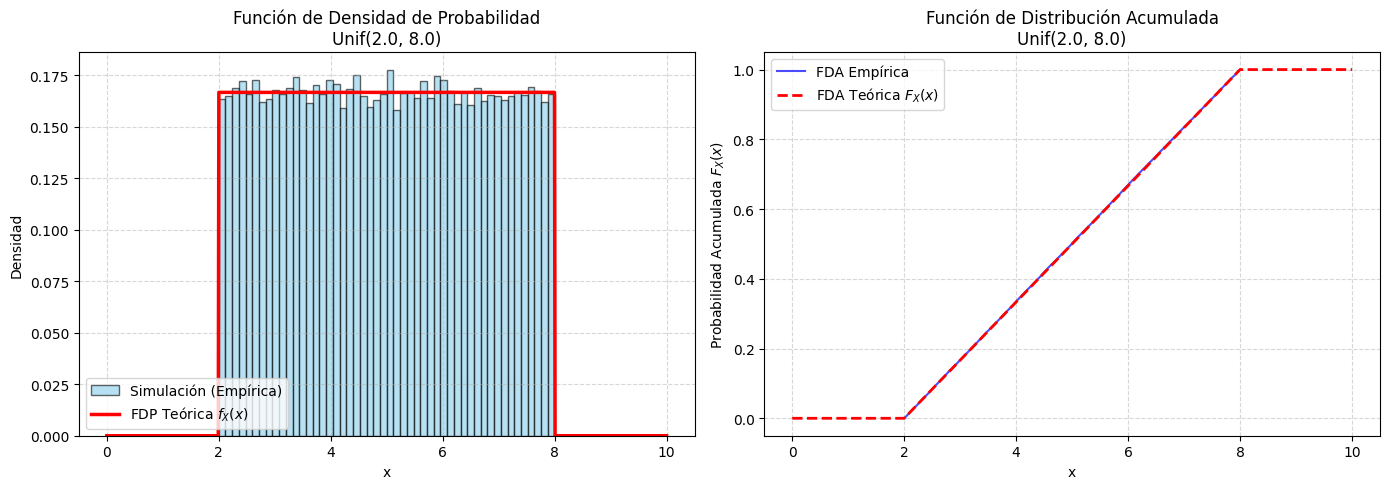

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Configuración de parámetros
a, b = 2.0, 8.0          # Intervalo [a, b]
num_muestras = 50000     # Tamaño de simulación

# 2. Generación de números aleatorios
np.random.seed(42)
muestras = np.random.uniform(a, b, num_muestras)

# Valores teóricos
media_teorica = (a + b) / 2
var_teorica = ((b - a)**2) / 12

# Valores empíricos
media_empirica = np.mean(muestras)
var_empirica = np.var(muestras)

print(f"--- COMPARACIÓN TEORÍA VS SIMULACIÓN ---")
print(f"Media Teórica : {media_teorica:.4f} | Media Empírica : {media_empirica:.4f}")
print(f"Var Teórica   : {var_teorica:.4f} | Var Empírica   : {var_empirica:.4f}\n")

# 3. Creación de Gráficas (FDP y FDA)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

x_teorico = np.linspace(a - 2, b + 2, 1000)

# Gráfica 1: Función de Densidad de Probabilidad (FDP)
ax[0].hist(muestras, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Simulación (Empírica)')
fdp_teorica = stats.uniform.pdf(x_teorico, loc=a, scale=b - a)
ax[0].plot(x_teorico, fdp_teorica, 'r-', lw=2.5, label='FDP Teórica $f_X(x)$')
ax[0].set_title(f'Función de Densidad de Probabilidad\nUnif({a}, {b})')
ax[0].set_xlabel('x')
ax[0].set_ylabel('Densidad')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

# Gráfica 2: Función de Distribución Acumulada (FDA)
x_sorted = np.sort(muestras)
y_empirico = np.arange(1, num_muestras + 1) / num_muestras

ax[1].plot(x_sorted, y_empirico, color='blue', lw=1.5, alpha=0.7, label='FDA Empírica')
fda_teorica = stats.uniform.cdf(x_teorico, loc=a, scale=b - a)
ax[1].plot(x_teorico, fda_teorica, 'r--', lw=2, label='FDA Teórica $F_X(x)$')
ax[1].set_title(f'Función de Distribución Acumulada\nUnif({a}, {b})')
ax[1].set_xlabel('x')
ax[1].set_ylabel('Probabilidad Acumulada $F_X(x)$')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Variable Aleatoria Exponencial

### Definición y Función de Densidad
La distribución exponencial es una de las distribuciones continuas más utilizadas en modelación estocástica. A menudo se utiliza para medir el **tiempo transcurrido entre eventos** que ocurren en un proceso de Poisson con tasa constante $\lambda > 0$.

**Ejemplos de aplicación:**
* El tiempo transcurrido en un call center hasta recibir la primera llamada del día.
* El tiempo entre terremotos de una determinada magnitud en una región dada.
* La cantidad de metros de alambre que produce una máquina hasta encontrar la primera falla.

Se dice que la variable aleatoria $X$ tiene una **distribución exponencial** con parámetro de tasa $\lambda > 0$ si su **Función de Densidad de Probabilidad (FDP)** está dada por:

$$f_{X}(x) = \begin{cases} \lambda e^{-\lambda x} & \text{si } x > 0 \\ 0 & \text{en otro caso} \end{cases}$$

**Notación:** $X \sim \text{Exp}(\lambda)$

---

### Función de Distribución Acumulada (FDA) y Función de Supervivencia

Por definición, $F_X(x) = \mathbb{P}(X \le x) = \int_{-\infty}^{x} f_X(t) \, dt$. Para $x > 0$:

$$F_X(x) = \int_0^x \lambda e^{-\lambda t} \, dt = \left[ -e^{-\lambda t} \right]_0^x = -e^{-\lambda x} - (-e^{0}) = 1 - e^{-\lambda x}$$

Por lo tanto, la **FDA** está dada por:

$$F_{X}(x) = \begin{cases} 1 - e^{-\lambda x} & \text{si } x \ge 0 \\ 0 & \text{si } x < 0 \end{cases}$$

De aquí se obtiene la **Función de Supervivencia** (probabilidad de la cola derecha):

$$S(x) = \mathbb{P}(X > x) = 1 - F_X(x) = e^{-\lambda x}$$

---

### Propiedad Fundamental: Pérdida de Memoria
Una de las propiedades más fascinantes e intuitivas de la distribución exponencial es que es la **única distribución continua que carece de memoria**:

$$\mathbb{P}(X > t + s \mid X > t) = \mathbb{P}(X > s) = e^{-\lambda s}, \quad \forall s, t > 0$$

**Demostración:**
Por definición de probabilidad condicional y considerando que la intersección $\{X > t + s\} \cap \{X > t\} = \{X > t + s\}$:

$$\mathbb{P}(X > t + s \mid X > t) = \frac{\mathbb{P}(X > t + s)}{\mathbb{P}(X > t)} = \frac{e^{-\lambda(t + s)}}{e^{-\lambda t}} = \frac{e^{-\lambda t} \cdot e^{-\lambda s}}{e^{-\lambda t}} = e^{-\lambda s} = \mathbb{P}(X > s) \quad \blacksquare$$

**¿Qué significa?** Si un equipo o foco ha funcionado ya durante $t$ horas sin fallar, la probabilidad de que funcione $s$ horas más es **exactamente la misma** que la de un equipo completamente nuevo funcionando durante $s$ horas. El proceso "no recuerda" cuánto tiempo ha transcurrido.

---

### Esperanza y Varianza (Deducción Analítica)

#### Esperanza Matemática ($\mathbb{E}[X]$)
Por definición para variables continuas:

$$\mathbb{E}[X] = \int_{0}^{\infty} x \cdot \lambda e^{-\lambda x} \, dx$$

Integrando por partes, asignando $u = x \implies du = dx$, y $dv = \lambda e^{-\lambda x} dx \implies v = -e^{-\lambda x}$:

$$\mathbb{E}[X] = \left[ -x e^{-\lambda x} \right]_0^{\infty} - \int_{0}^{\infty} (-e^{-\lambda x}) \, dx = 0 + \left[ -\frac{1}{\lambda} e^{-\lambda x} \right]_0^{\infty} = 0 - \left( -\frac{1}{\lambda} \right) = \frac{1}{\lambda}$$

#### Varianza ($\text{Var}(X)$)
Calculamos primero el segundo momento $\mathbb{E}[X^2]$ integrando por partes de nuevo ($u = x^2 \implies du = 2x \, dx$; $dv = \lambda e^{-\lambda x} dx \implies v = -e^{-\lambda x}$):

$$\mathbb{E}[X^2] = \int_{0}^{\infty} x^2 \lambda e^{-\lambda x} \, dx = \left[ -x^2 e^{-\lambda x} \right]_0^{\infty} + 2 \int_{0}^{\infty} x e^{-\lambda x} \, dx$$

Note que la última integral es $\frac{2}{\lambda} \mathbb{E}[X] = \frac{2}{\lambda} \left(\frac{1}{\lambda}\right) = \frac{2}{\lambda^2}$.

Ahora restamos el cuadrado de la esperanza:

$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{2}{\lambda^2} - \left(\frac{1}{\lambda}\right)^2 = \frac{2}{\lambda^2} - \frac{1}{\lambda^2} = \frac{1}{\lambda^2}$$

---

### Observación (Parametrización Alternativa en Términos de la Media)
A veces en ingeniería y estadística aplicada se parametriza en función de la media escala $\mu = \frac{1}{\lambda}$ en lugar de la tasa $\lambda$:

$$f_{X}(x) = \begin{cases} \frac{1}{\mu} e^{-x/\mu} & \text{si } x > 0 \\ 0 & \text{en otro caso} \end{cases}$$

Con esta parametrización:
* $\mathbb{E}[X] = \mu$
* $\text{Var}(X) = \mu^2$

*Es la misma distribución; solo cambia la forma de nombrar al parámetro.*



<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\l'
<>:51: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1595/1078829954.py:32: SyntaxWarning: invalid escape sequence '\l'
  ax[0].hist(muestras, bins=60, density=True, alpha=0.4, color='skyblue', edgecolor='black', label=f'Simulación ($\lambda={lam}$)')
/tmp/ipykernel_1595/1078829954.py:38: SyntaxWarning: invalid escape sequence '\l'
  ax[0].set_title('Función de Densidad de Probabilidad (FDP)\n$f_X(x) = \lambda e^{-\lambda x}$')
/tmp/ipykernel_1595/1078829954.py:48: SyntaxWarning: invalid escape sequence '\l'
  ax[1].plot(x

--- COMPARACIÓN TEORÍA VS SIMULACIÓN (Exp(lambda=1.5)) ---
Media Teórica : 0.6667 | Media Empírica : 0.6641
Var Teórica   : 0.4444 | Var Empírica   : 0.4415



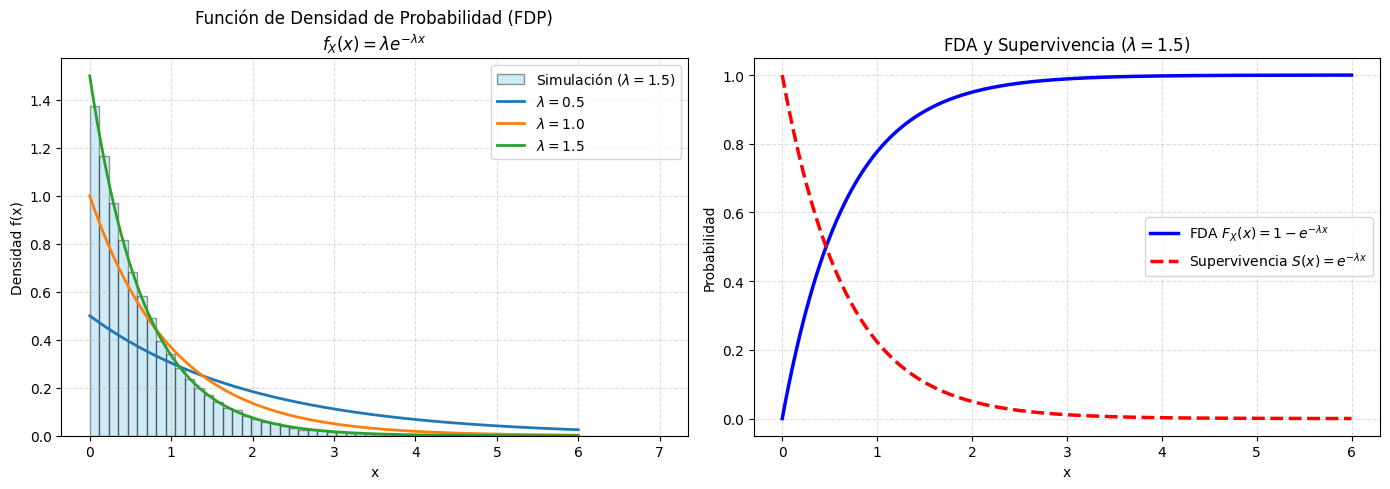

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Configuración de parámetros para la simulación
lam = 1.5                # Tasa lambda
num_muestras = 50000     # Tamaño de simulación

# 2. Generación de números aleatorios (Método Directo y Scipy)
np.random.seed(42)
muestras = np.random.exponential(scale=1/lam, size=num_muestras)

# Cálculos Teóricos vs Empíricos
media_teorica = 1 / lam
var_teorica = 1 / (lam**2)

media_empirica = np.mean(muestras)
var_empirica = np.var(muestras)

print(f"--- COMPARACIÓN TEORÍA VS SIMULACIÓN (Exp(lambda={lam})) ---")
print(f"Media Teórica : {media_teorica:.4f} | Media Empírica : {media_empirica:.4f}")
print(f"Var Teórica   : {var_teorica:.4f} | Var Empírica   : {var_empirica:.4f}\n")

# 3. Creación de Gráficas de Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- GRÁFICA 1: FDP para distintos valores de Lambda y Simulación ---
x = np.linspace(0, 6, 500)
lambdas = [0.5, 1.0, 1.5]

# Histograma de las muestras simuladas para lambda = 1.5
ax[0].hist(muestras, bins=60, density=True, alpha=0.4, color='skyblue', edgecolor='black', label=f'Simulación ($\lambda={lam}$)')

# Curvas teóricas para distintos lambdas
for l in lambdas:
    ax[0].plot(x, l * np.exp(-l * x), lw=2, label=fr'$\lambda={l}$')

ax[0].set_title('Función de Densidad de Probabilidad (FDP)\n$f_X(x) = \lambda e^{-\lambda x}$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('Densidad f(x)')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.4)

# --- GRÁFICA 2: FDA y Función de Supervivencia ---
fda_teorica = stats.expon.cdf(x, scale=1/lam)
supervivencia_teorica = 1 - fda_teorica

ax[1].plot(x, fda_teorica, 'b-', lw=2.5, label='FDA $F_X(x) = 1 - e^{-\lambda x}$')
ax[1].plot(x, supervivencia_teorica, 'r--', lw=2.5, label='Supervivencia $S(x) = e^{-\lambda x}$')

ax[1].set_title(f'FDA y Supervivencia ($\lambda={lam}$)')
ax[1].set_xlabel('x')
ax[1].set_ylabel('Probabilidad')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 4. Variable Aleatoria Gamma

### Definición y Función Gamma
La distribución Gamma es una generalización de la distribución exponencial. Modela el tiempo que transcurre hasta que ocurren $\alpha$ eventos independientes en un proceso de Poisson con tasa constante $\lambda > 0$.

Antes de definir la variable aleatoria, se define la **Función Gamma** $\Gamma:(0,\infty) \to \mathbb{R}$ como:

$$\Gamma(\alpha) = \int_{0}^{\infty} t^{\alpha-1} e^{-t} \, dt$$

#### Propiedades de la Función Gamma:
* $\Gamma(\alpha) < \infty$ para cualquier $\alpha > 0$.
* $\Gamma(\alpha + 1) = \alpha \Gamma(\alpha)$ (Propiedad recursiva).
* Si $n \in \mathbb{Z}^+$, entonces $\Gamma(n) = (n - 1)!$
* $\Gamma\left(\frac{1}{2}\right) = \sqrt{\pi}$.

---

### Función de Densidad de Probabilidad (FDP)
Decimos que una variable aleatoria continua $X$ sigue una **distribución Gamma** con parámetro de forma (o número de eventos) $\alpha > 0$ y parámetro de tasa $\lambda > 0$ si su FDP está dada por:

$$f_{X}(x) = \begin{cases} \frac{\lambda^{\alpha} x^{\alpha-1} e^{-\lambda x}}{\Gamma(\alpha)} & \text{si } x > 0 \\ 0 & \text{en otro caso} \end{cases}$$

**Notación:** $X \sim \Gamma(\alpha, \lambda)$

---

### Casos Especiales y Relaciones Importantes
* **Distribución Exponencial:** Si $\alpha = 1$, obtenemos $X \sim \text{Exp}(\lambda)$.
* **Distribución Chi-Cuadrada ($\chi^2_k$):** Si $\alpha = \frac{k}{2}$ y $\lambda = \frac{1}{2}$ (con $k \in \mathbb{Z}^+$), se obtiene la distribución Chi-cuadrada con $k$ grados de libertad.
* **Distribución Erlang:** Si $\alpha = k$ (un entero positivo $k \ge 1$), la distribución Gamma se denomina distribución Erlang, ampliamente usada en ingeniería de tráfico y teoría de colas.

---

### Esperanza y Varianza (Deducción Analítica)

#### Esperanza Matemática ($\mathbb{E}[X]$)
$$\mathbb{E}[X] = \int_{0}^{\infty} x \cdot \frac{\lambda^{\alpha} x^{\alpha-1} e^{-\lambda x}}{\Gamma(\alpha)} \, dx = \frac{\lambda^{\alpha}}{\Gamma(\alpha)} \int_{0}^{\infty} x^{\alpha} e^{-\lambda x} \, dx$$

Haciendo el cambio de variable $u = \lambda x \implies x = \frac{u}{\lambda}$ y $dx = \frac{du}{\lambda}$:

$$\mathbb{E}[X] = \frac{\lambda^{\alpha}}{\Gamma(\alpha)} \int_{0}^{\infty} \left(\frac{u}{\lambda}\right)^{\alpha} e^{-u} \frac{du}{\lambda} = \frac{\lambda^{\alpha}}{\Gamma(\alpha) \cdot \lambda^{\alpha+1}} \int_{0}^{\infty} u^{(\alpha+1)-1} e^{-u} \, du$$

Usando la definición de la función Gamma $\int_{0}^{\infty} u^{(\alpha+1)-1} e^{-u} \, du = \Gamma(\alpha + 1)$:

$$\mathbb{E}[X] = \frac{\Gamma(\alpha + 1)}{\lambda \Gamma(\alpha)} = \frac{\alpha \Gamma(\alpha)}{\lambda \Gamma(\alpha)} = \frac{\alpha}{\lambda}$$

#### Varianza ($\text{Var}(X)$)
Calculamos primero el segundo momento $\mathbb{E}[X^2]$ aplicando la misma sustitución:

$$\mathbb{E}[X^2] = \int_{0}^{\infty} x^2 \frac{\lambda^{\alpha} x^{\alpha-1} e^{-\lambda x}}{\Gamma(\alpha)} \, dx = \frac{\lambda^{\alpha}}{\Gamma(\alpha)} \int_{0}^{\infty} x^{\alpha+1} e^{-\lambda x} \, dx = \frac{\Gamma(\alpha + 2)}{\lambda^2 \Gamma(\alpha)}$$

Como $\Gamma(\alpha + 2) = (\alpha + 1)\alpha \Gamma(\alpha)$:

$$\mathbb{E}[X^2] = \frac{(\alpha + 1)\alpha}{\lambda^2}$$

Restando el cuadrado de la esperanza:

$$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{\alpha^2 + \alpha}{\lambda^2} - \frac{\alpha^2}{\lambda^2} = \frac{\alpha}{\lambda^2}$$

---

### Aplicaciones Prácticas en Ciencia de Datos
1. **Teoría de Colas:** Tiempo de espera acumulado hasta recibir $k$ llamadas en un call center o servidores informáticos.
2. **Análisis de Supervivencia y Confiabilidad:** Tiempo total hasta el fallo de un sistema con componentes de respaldo encadenados.
3. **Hidrología y Meteorología:** Modelado de la cantidad acumulada de precipitación pluvial en periodos determinados.
4. **Finanzas:** Modelado de volatilidades y rendimientos de activos financieros con colas pesadas.

<>:35: SyntaxWarning: invalid escape sequence '\G'
<>:35: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_1595/1959115079.py:35: SyntaxWarning: invalid escape sequence '\G'
  ax[0].plot(x, fdp_teorica, 'r-', lw=2.5, label=f'FDP Teórica $\Gamma(\\alpha={alpha}, \\lambda={lambd})$')


--- COMPARACIÓN TEORÍA VS SIMULACIÓN (Gamma(alpha=3.0, lambda=0.5)) ---
Media Teórica : 6.0000 | Media Empírica : 6.0155
Var Teórica   : 12.0000 | Var Empírica   : 12.0030



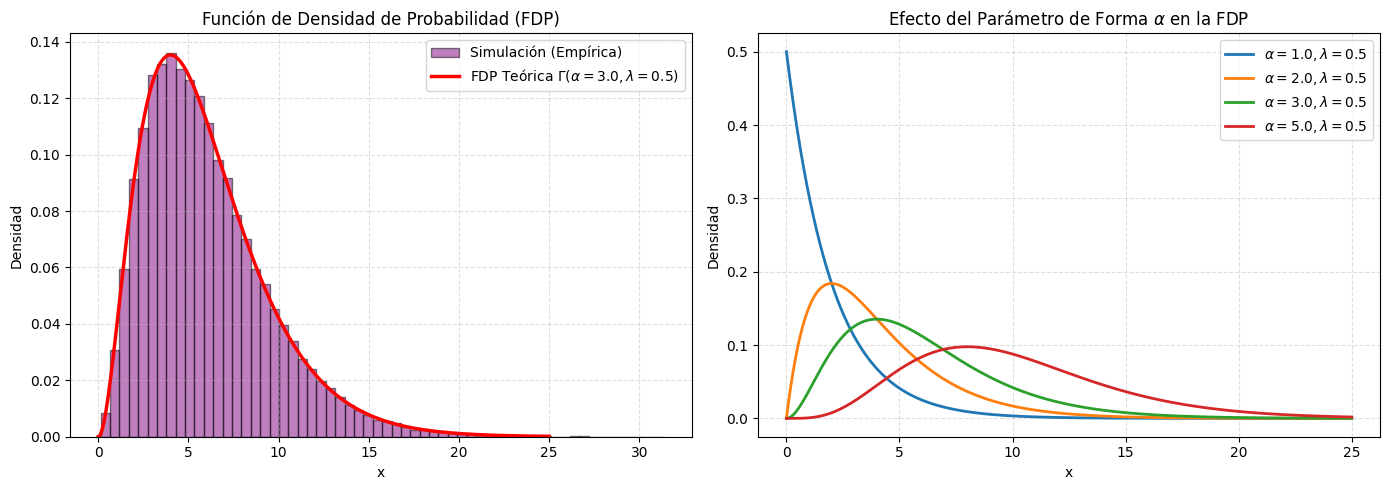

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# 1. Configuración de parámetros
alpha = 3.0              # Parámetro de forma (número de eventos)
lambd = 0.5              # Parámetro de tasa
scale = 1 / lambd        # Parámetro de escala para SciPy (θ = 1 / λ)
num_muestras = 50000     # Tamaño de simulación

# 2. Generación de muestras (Simulación algorítmica)
np.random.seed(42)
muestras = np.random.gamma(shape=alpha, scale=scale, size=num_muestras)

# Valores teóricos
media_teorica = alpha / lambd
var_teorica = alpha / (lambd**2)

# Valores empíricos
media_empirica = np.mean(muestras)
var_empirica = np.var(muestras)

print(f"--- COMPARACIÓN TEORÍA VS SIMULACIÓN (Gamma(alpha={alpha}, lambda={lambd})) ---")
print(f"Media Teórica : {media_teorica:.4f} | Media Empírica : {media_empirica:.4f}")
print(f"Var Teórica   : {var_teorica:.4f} | Var Empírica   : {var_empirica:.4f}\n")

# 3. Creación de Gráficas de Visualización
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

x = np.linspace(0, 25, 1000)

# --- GRÁFICA 1: Histograma Empírico vs FDP Teórica ---
ax[0].hist(muestras, bins=60, density=True, alpha=0.5, color='purple', edgecolor='black', label='Simulación (Empírica)')
fdp_teorica = stats.gamma.pdf(x, a=alpha, scale=scale)
ax[0].plot(x, fdp_teorica, 'r-', lw=2.5, label=f'FDP Teórica $\Gamma(\\alpha={alpha}, \\lambda={lambd})$')
ax[0].set_title('Función de Densidad de Probabilidad (FDP)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('Densidad')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.4)

# --- GRÁFICA 2: Sensibilidad de la FDP a diferentes valores de alpha ---
alphas_test = [1.0, 2.0, 3.0, 5.0]
for a_val in alphas_test:
    fdp_a = stats.gamma.pdf(x, a=a_val, scale=scale)
    ax[1].plot(x, fdp_a, lw=2, label=f'$\\alpha={a_val}, \\lambda={lambd}$')

ax[1].set_title('Efecto del Parámetro de Forma $\\alpha$ en la FDP')
ax[1].set_xlabel('x')
ax[1].set_ylabel('Densidad')
ax[1].legend()
ax[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##  Función Generadora de Momentos (FGM)

### Definición
Sea $X$ una variable aleatoria (discreta o continua). La **Función Generadora de Momentos (FGM)** de $X$, denotada por $M_X(t)$, se define como el valor esperado de $e^{tX}$:

$$M_X(t) = \mathbb{E}[e^{tX}]$$

* **Caso Discreto:** $M_X(t) = \sum_{x} e^{tx} \, p_X(x)$
* **Caso Continuo:** $M_X(t) = \int_{-\infty}^{\infty} e^{tx} \, f_X(x) \, dx$

La FGM existe si la esperanza es finita para todos los valores de $t$ en un intervalo abierto alrededor del origen, es decir, para $|t| < h$ con $h > 0$.

---

### Propiedades Fundamentales

1. **Evaluación en el origen:** $M_X(0) = \mathbb{E}[e^{0}] = \mathbb{E}[1] = 1$.
2. **Unicidad:** Si dos variables aleatorias $X$ e $Y$ tienen la misma FGM en un entorno de $t=0$ ($M_X(t) = M_Y(t)$), entonces $X$ e $Y$ tienen exactamente la misma distribución de probabilidad.
3. **Transformación Afín:** Si $Y = aX + b$, donde $a, b \in \mathbb{R}$, entonces:
   $$M_Y(t) = \mathbb{E}[e^{t(aX+b)}] = e^{bt} \mathbb{E}[e^{(at)X}] = e^{bt} M_X(at)$$
4. **Suma de Variables Independientes:** Si $X_1, X_2, \dots, X_n$ son variables aleatorias independientes, y $Y = \sum_{i=1}^n X_i$, entonces la FGM de la suma es el producto de las FGM individuales:
   $$M_Y(t) = \prod_{i=1}^{n} M_{X_i}(t)$$

---

### Obtención de Momentos

Expandiendo $e^{tX}$ en su serie de Taylor (Maclaurin) alrededor de $t = 0$:

$$e^{tX} = \sum_{k=0}^{\infty} \frac{(tX)^k}{k!} = 1 + tX + \frac{t^2 X^2}{2!} + \frac{t^3 X^3}{3!} + \dots$$

Aplicando el operador esperanza a ambos lados:

$$M_X(t) = \mathbb{E}\left[ \sum_{k=0}^{\infty} \frac{t^k X^k}{k!} \right] = \sum_{k=0}^{\infty} \frac{t^k}{k!} \mathbb{E}[X^k]$$

Por lo tanto, el $n$-ésimo momento no centrado $\mu_n' = \mathbb{E}[X^n]$ es el coeficiente de $\frac{t^n}{n!}$ en el desarrollo en serie.

Alternativamente, derivando $n$ veces $M_X(t)$ con respecto a $t$ y evaluando en $t = 0$:

$$M_X^{(n)}(0) = \left. \frac{d^n M_X(t)}{dt^n} \right|_{t=0} = \mathbb{E}[X^n]$$

En particular:
* **Primer momento (Esperanza):** $\mathbb{E}[X] = M_X'(0)$
* **Segundo momento:** $\mathbb{E}[X^2] = M_X''(0)$
* **Varianza:** $\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = M_X''(0) - [M_X'(0)]^2$

---

### Ejemplo Analítico: Variable Aleatoria Exponencial

Sea $X \sim \text{Exp}(\lambda)$ con densidad $f_X(x) = \lambda e^{-\lambda x}$ para $x > 0$.

#### 1. Cálculo de $M_X(t)$:
$$M_X(t) = \mathbb{E}[e^{tX}] = \int_{0}^{\infty} e^{tx} \cdot \lambda e^{-\lambda x} \, dx = \lambda \int_{0}^{\infty} e^{-( \lambda - t ) x} \, dx$$

Para que la integral converja, se requiere que $t < \lambda$:

$$M_X(t) = \lambda \left[ \frac{-e^{-(\lambda - t) x}}{\lambda - t} \right]_{0}^{\infty} = \lambda \left( 0 - \left( -\frac{1}{\lambda - t} \right) \right) = \frac{\lambda}{\lambda - t} = \left( 1 - \frac{t}{\lambda} \right)^{-1}, \quad t < \lambda$$

#### 2. Obtención de Momentos mediante Derivación:

* **Primera derivada ($M_X'(t)$):**
  $$M_X'(t) = \frac{d}{dt} \left[ \lambda (\lambda - t)^{-1} \right] = \lambda (\lambda - t)^{-2}$$
  $$\mathbb{E}[X] = M_X'(0) = \frac{\lambda}{\lambda^2} = \frac{1}{\lambda}$$

* **Segunda derivada ($M_X''(t)$):**
  $$M_X''(t) = \frac{d}{dt} \left[ \lambda (\lambda - t)^{-2} \right] = 2\lambda (\lambda - t)^{-3}$$
  $$\mathbb{E}[X^2] = M_X''(0) = \frac{2\lambda}{\lambda^3} = \frac{2}{\lambda^2}$$

* **Varianza:**
  $$\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{2}{\lambda^2} - \left(\frac{1}{\lambda}\right)^2 = \frac{1}{\lambda^2}$$

<>:71: SyntaxWarning: invalid escape sequence '\s'
<>:71: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1595/2874943088.py:71: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Función Generadora de Momentos para $X \sim Exp(\lambda = {lmbda_val})$')


=== CÁLCULO SIMBÓLICO CON SYMPY ===
FGM M_X(t)   : lambda/(lambda - t)
M'_X(t)      : lambda/(lambda - t)**2
E[X]         : 1/lambda
E[X^2]       : 2/lambda**2
Var(X)       : lambda**(-2)

=== VERIFICACIÓN NUMÉRICA (lambda = 2.0) ===
E[X] Teórico : 0.5000 | E[X] Empírico : 0.5014
Var(X) Teórica: 0.2500 | Var(X) Empírica: 0.2516



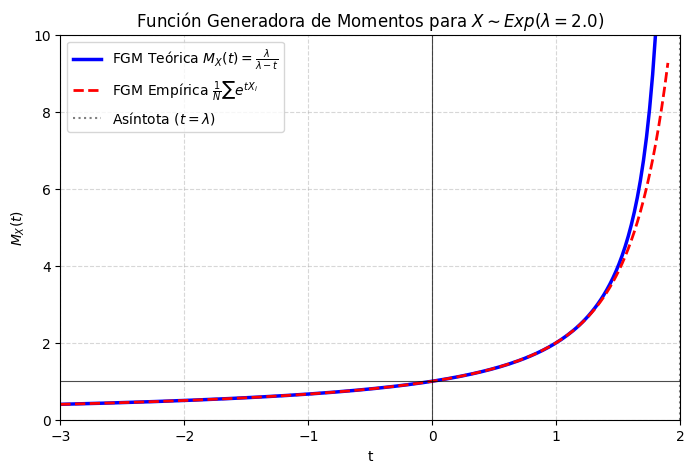

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CÁLCULO SIMBÓLICO DE MOMENTOS CON SYMPY
# ==========================================
t, x, lmbda = sp.symbols('t x lambda', real=True, positive=True)

# Definimos la FDP de la distribución Exponencial
fdp_exp = lmbda * sp.exp(-lmbda * x)

# Calculamos la FGM: M_X(t) = E[e^(tX)]
M_X = sp.integrate(sp.exp(t * x) * fdp_exp, (x, 0, sp.oo))
# Simplificamos condicionado a t < lambda
M_X_simp = lmbda / (lmbda - t)

# Derivadas respecto a t
d1_M = sp.diff(M_X_simp, t)
d2_M = sp.diff(M_X_simp, t, 2)

# Momentos evaluando en t = 0
E_X_simbolica = d1_M.subs(t, 0)
E_X2_simbolica = d2_M.subs(t, 0)
Var_X_simbolica = sp.simplify(E_X2_simbolica - E_X_simbolica**2)

print("=== CÁLCULO SIMBÓLICO CON SYMPY ===")
print(f"FGM M_X(t)   : {M_X_simp}")
print(f"M'_X(t)      : {d1_M}")
print(f"E[X]         : {E_X_simbolica}")
print(f"E[X^2]       : {E_X2_simbolica}")
print(f"Var(X)       : {Var_X_simbolica}\n")

# ==========================================
# 2. VERIFICACIÓN NUMÉRICA Y SIMULACIÓN
# ==========================================
lmbda_val = 2.0
num_samples = 100000

# Simulación Monte Carlo de Exp(lambda = 2.0)
muestras = np.random.exponential(scale=1/lmbda_val, size=num_samples)

# Momentos teóricos evaluados
E_X_teorico = float(E_X_simbolica.subs(lmbda, lmbda_val))
Var_X_teorico = float(Var_X_simbolica.subs(lmbda, lmbda_val))

# Momentos empíricos
E_X_empirico = np.mean(muestras)
Var_X_empirico = np.var(muestras)

print("=== VERIFICACIÓN NUMÉRICA (lambda = 2.0) ===")
print(f"E[X] Teórico : {E_X_teorico:.4f} | E[X] Empírico : {E_X_empirico:.4f}")
print(f"Var(X) Teórica: {Var_X_teorico:.4f} | Var(X) Empírica: {Var_X_empirico:.4f}\n")

# ==========================================
# 3. GRAFICACIÓN DE LA FGM
# ==========================================
t_vals = np.linspace(-3, lmbda_val - 0.1, 200)
M_t_teorico = lmbda_val / (lmbda_val - t_vals)

# Estimación de M_X(t) vía Monte Carlo: E[e^(tX)] ≈ (1/N) * sum(exp(t * x_i))
M_t_empirico = [np.mean(np.exp(t_i * muestras)) for t_i in t_vals]

plt.figure(figsize=(8, 5))
plt.plot(t_vals, M_t_teorico, 'b-', lw=2.5, label=r'FGM Teórica $M_X(t) = \frac{\lambda}{\lambda - t}$')
plt.plot(t_vals, M_t_empirico, 'r--', lw=2, label=r'FGM Empírica $\frac{1}{N} \sum e^{t X_i}$')
plt.axvline(x=lmbda_val, color='gray', linestyle=':', label=r'Asíntota ($t = \lambda$)')
plt.axvline(x=0, color='black', linewidth=0.8, alpha=0.7)
plt.axhline(y=1, color='black', linewidth=0.8, alpha=0.7)

plt.title(f'Función Generadora de Momentos para $X \sim Exp(\lambda = {lmbda_val})$')
plt.xlabel('t')
plt.ylabel('$M_X(t)$')
plt.ylim(0, 10)
plt.xlim(-3, lmbda_val)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Función Característica (FC)

### Definición
Sea $X$ una variable aleatoria (discreta o continua). La **Función Característica (FC)** de $X$, denotada por $\varphi_X(t)$, se define como el valor esperado de la variable aleatoria compleja $e^{itX}$:

$$\varphi_X(t) = \mathbb{E}[e^{itX}]$$

donde $i = \sqrt{-1}$ es la unidad imaginaria y $t \in \mathbb{R}$.

Utilizando la **Fórmula de Euler** ($e^{itX} = \cos(tX) + i \sin(tX)$), la función característica se expresa como:

$$\varphi_X(t) = \mathbb{E}[\cos(tX)] + i \, \mathbb{E}[\sin(tX)]$$

* **Caso Discreto:** $\varphi_X(t) = \sum_{x} e^{itx} \, p_X(x)$
* **Caso Continuo:** $\varphi_X(t) = \int_{-\infty}^{\infty} e^{itx} \, f_X(x) \, dx$

> **Nota Clave:** A diferencia de la Función Generadora de Momentos (FGM), la Función Característica **siempre existe** para cualquier variable aleatoria $X$, ya que $|e^{itX}| = 1$ y por lo tanto $|\varphi_X(t)| \le \mathbb{E}[|e^{itX}|] = 1$ para todo $t \in \mathbb{R}$.

---

### Propiedades Fundamentales

1. **Evaluación en el origen:** $\varphi_X(0) = \mathbb{E}[e^{0}] = 1$.
2. **Acotamiento:** $|\varphi_X(t)| \le 1$ para todo $t \in \mathbb{R}$.
3. **Simetría Hermitiana:** $\varphi_X(-t) = \overline{\varphi_X(t)}$, donde la barra denota el conjugado complejo. Si $X$ es simétrica respecto a 0, entonces $\varphi_X(t)$ es puramente real.
4. **Transformación Afín:** Si $Y = aX + b$ con $a, b \in \mathbb{R}$, entonces:
   $$\varphi_Y(t) = \mathbb{E}[e^{it(aX+b)}] = e^{itb} \, \varphi_X(at)$$
5. **Suma de Variables Independientes:** Si $X_1, X_2, \dots, X_n$ son independientes y $Y = \sum_{j=1}^n X_j$, entonces:
   $$\varphi_Y(t) = \prod_{j=1}^{n} \varphi_{X_j}(t)$$
6. **Teorema de Unicidad:** La función característica determina de manera única la función de distribución acumulada $F_X(x)$ mediante la **fórmula de inversión de Fourier**.

---

### Relación con los Momentos

Si el $n$-ésimo momento no centrado $\mathbb{E}[X^n]$ existe y es finito, entonces $\varphi_X(t)$ es $n$ veces diferenciable en $t=0$.

Expandiendo $e^{itX}$ en su serie de Maclaurin:

$$\varphi_X(t) = \mathbb{E}\left[ \sum_{k=0}^{\infty} \frac{(itX)^k}{k!} \right] = \sum_{k=0}^{\infty} \frac{(it)^k}{k!} \mathbb{E}[X^k]$$

Derivando $n$ veces con respecto a $t$ y evaluando en $t = 0$:

$$\varphi_X^{(n)}(0) = \left. \frac{d^n \varphi_X(t)}{dt^n} \right|_{t=0} = i^n \, \mathbb{E}[X^n]$$

Despejando los momentos:

$$\mathbb{E}[X^n] = \frac{1}{i^n} \left. \frac{d^n \varphi_X(t)}{dt^n} \right|_{t=0} = (-i)^n \, \varphi_X^{(n)}(0)$$

En particular:
* **Primer momento (Esperanza):** $\mathbb{E}[X] = -i \, \varphi_X'(0)$
* **Segundo momento:** $\mathbb{E}[X^2] = -\varphi_X''(0)$
* **Varianza:** $\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = -\varphi_X''(0) - \left[ -i \, \varphi_X'(0) \right]^2$

---

### Ejemplo Analítico: Distribución Normal Estándar $Z \sim \mathcal{N}(0, 1)$

Sea $Z \sim \mathcal{N}(0, 1)$ con función de densidad $f_Z(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}$.

#### 1. Cálculo de $\varphi_Z(t)$:
$$\varphi_Z(t) = \mathbb{E}[e^{itZ}] = \int_{-\infty}^{\infty} e^{itz} \cdot \frac{1}{\sqrt{2\pi}} e^{-z^2/2} \, dz = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} e^{-\frac{1}{2}(z^2 - 2itz)} \, dz$$

Completando el cuadrado en el exponente: $z^2 - 2itz = (z - it)^2 + t^2$

$$\varphi_Z(t) = e^{-t^2/2} \left[ \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{\infty} e^{-\frac{1}{2}(z - it)^2} \, dz \right] = e^{-t^2/2}$$

#### 2. Obtención de Momentos mediante Derivación:

* **Primera derivada ($\varphi_Z'(t)$):**
  $$\varphi_Z'(t) = \frac{d}{dt} \left[ e^{-t^2/2} \right] = -t e^{-t^2/2}$$
  $$\mathbb{E}[Z] = -i \, \varphi_Z'(0) = -i (0) = 0$$

* **Segunda derivada ($\varphi_Z''(t)$):**
  $$\varphi_Z''(t) = \frac{d}{dt} \left[ -t e^{-t^2/2} \right] = (t^2 - 1) e^{-t^2/2}$$
  $$\mathbb{E}[Z^2] = -\varphi_Z''(0) = -(-1) = 1$$

* **Varianza:**
  $$\text{Var}(Z) = \mathbb{E}[Z^2] - (\mathbb{E}[Z])^2 = 1 - 0 = 1$$

<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:65: SyntaxWarning: invalid escape sequence '\p'
<>:67: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1595/1006628204.py:55: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Parte Real de $\phi_Z(t)$')
/tmp/ipykernel_1595/1006628204.py:57: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Re($\phi$)')
/tmp/ipykernel_1595/1006628204.py:65: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Parte Imaginaria de $\phi_Z(t)$')
/tmp/ipykernel_1595/1006628204.py:67: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Im($\phi$)')


=== CÁLCULO SIMBÓLICO CON SYMPY (Normal Estándar) ===
FC phi_Z(t)  : (2 - erfc(sqrt(2)*I*t/2))*exp(-t**2/2)/2 + exp(-t**2/2)*erfc(sqrt(2)*I*t/2)/2
phi'_Z(t)    : -t*(2 - erfc(sqrt(2)*I*t/2))*exp(-t**2/2)/2 - t*exp(-t**2/2)*erfc(sqrt(2)*I*t/2)/2
phi''_Z(t)   : (-t**2*(erfc(sqrt(2)*I*t/2) - 2) + t**2*erfc(sqrt(2)*I*t/2) - 2)*exp(-t**2/2)/2
E[Z]         : 0
E[Z^2]       : 1
Var(Z)       : 1



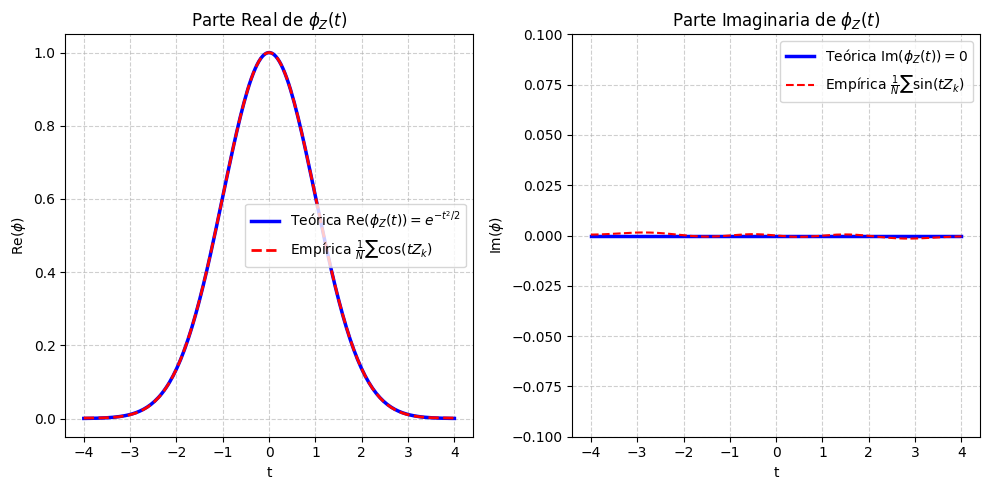

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CÁLCULO SIMBÓLICO DE FC Y MOMENTOS CON SYMPY
# ==========================================
t, z = sp.symbols('t z', real=True)

# Densidad de la Normal Estándar N(0,1)
fdp_normal = (1 / sp.sqrt(2 * sp.pi)) * sp.exp(-z**2 / 2)

# Función Característica: phi_Z(t) = E[e^(i*t*Z)]
phi_Z = sp.integrate(sp.exp(sp.I * t * z) * fdp_normal, (z, -sp.oo, sp.oo))

# Derivadas de phi_Z respecto a t
d1_phi = sp.diff(phi_Z, t)
d2_phi = sp.diff(phi_Z, t, 2)

# Obtención de momentos usando -i * phi'(0) y (-i)^2 * phi''(0)
E_Z_simbolico = (-sp.I * d1_phi).subs(t, 0)
E_Z2_simbolico = (-d2_phi).subs(t, 0)
Var_Z_simbolica = E_Z2_simbolico - (E_Z_simbolico)**2

print("=== CÁLCULO SIMBÓLICO CON SYMPY (Normal Estándar) ===")
print(f"FC phi_Z(t)  : {phi_Z}")
print(f"phi'_Z(t)    : {d1_phi}")
print(f"phi''_Z(t)   : {d2_phi}")
print(f"E[Z]         : {E_Z_simbolico}")
print(f"E[Z^2]       : {E_Z2_simbolico}")
print(f"Var(Z)       : {Var_Z_simbolica}\n")

# ==========================================
# 2. VERIFICACIÓN NUMÉRICA Y MONTE CARLO
# ==========================================
N = 100000
muestras_Z = np.random.normal(loc=0.0, scale=1.0, size=N)

# Evaluación empírica de phi_Z(t) = E[cos(tZ)] + i*E[sin(tZ)]
t_grid = np.linspace(-4, 4, 200)

phi_teorico = np.exp(-t_grid**2 / 2)
phi_empirico_real = [np.mean(np.cos(t_val * muestras_Z)) for t_val in t_grid]
phi_empirico_imag = [np.mean(np.sin(t_val * muestras_Z)) for t_val in t_grid]

# ==========================================
# 3. GRAFICACIÓN DE LA FUNCIÓN CARACTERÍSTICA
# ==========================================
plt.figure(figsize=(10, 5))

# Parte Real
plt.subplot(1, 2, 1)
plt.plot(t_grid, phi_teorico, 'b-', lw=2.5, label=r'Teórica $\text{Re}(\phi_Z(t)) = e^{-t^2/2}$')
plt.plot(t_grid, phi_empirico_real, 'r--', lw=2, label=r'Empírica $\frac{1}{N}\sum \cos(t Z_k)$')
plt.title('Parte Real de $\phi_Z(t)$')
plt.xlabel('t')
plt.ylabel('Re($\phi$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Parte Imaginaria (debe ser cercana a 0 por simetría)
plt.subplot(1, 2, 2)
plt.plot(t_grid, np.zeros_like(t_grid), 'b-', lw=2.5, label=r'Teórica $\text{Im}(\phi_Z(t)) = 0$')
plt.plot(t_grid, phi_empirico_imag, 'r--', lw=1.5, label=r'Empírica $\frac{1}{N}\sum \sin(t Z_k)$')
plt.title('Parte Imaginaria de $\phi_Z(t)$')
plt.xlabel('t')
plt.ylabel('Im($\phi$)')
plt.ylim(-0.1, 0.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

##  Ley de los Grandes Números (LGN)

### Explicación e Idea Central
[cite_start]La **Ley de los Grandes Números (LGN)** es uno de los teoremas fundamentales de la teoría de la probabilidad[cite: 16]. [cite_start]Establece que si realizamos un mismo experimento aleatorio una gran cantidad de veces de forma independiente, el **promedio muestral** de los resultados observados convergerá al verdadero **valor esperado (media teórica $\mu$)** de la distribución subyacente[cite: 17].

Formalmente, sean $X_1, X_2, \dots, X_n$ variables aleatorias independientes e idénticamente distribuidas (i.i.d.) con esperanza finita $\mathbb{E}[X_i] = \mu$ y varianza finita $\text{Var}(X_i) = \sigma^2$.

Definimos el promedio muestral para una muestra de tamaño $n$ como:

$$\bar{X}_n = \frac{1}{n} \sum_{i=1}^{n} X_i$$

#### Propiedades del Promedio Muestral:
1. **Insesgadez:** $\mathbb{E}[\bar{X}_n] = \mathbb{E}\left[ \frac{1}{n} \sum_{i=1}^n X_i \right] = \frac{1}{n} \sum_{i=1}^n \mathbb{E}[X_i] = \frac{1}{n} (n\mu) = \mu$
2. **Varianza decreciente:** $\text{Var}(\bar{X}_n) = \text{Var}\left( \frac{1}{n} \sum_{i=1}^n X_i \right) = \frac{1}{n^2} \sum_{i=1}^n \text{Var}(X_i) = \frac{1}{n^2} (n\sigma^2) = \frac{\sigma^2}{n}$

Como $\lim_{n \to \infty} \text{Var}(\bar{X}_n) = 0$, la incertidumbre alrededor de la media muestral tiende a desaparecer a medida que $n$ crece.

---

### Versiones de la Ley de los Grandes Números

Existen dos formalizaciones matemáticas de este principio según el tipo de convergencia estocástica:

#### 1. Ley Débil de los Grandes Números (LDGN)
Garantiza **convergencia en probabilidad**. Para todo $\epsilon > 0$, la probabilidad de que la media muestral difiera de la media teórica por más de $\epsilon$ tiende a cero a medida que $n \to \infty$:

$$\lim_{n \to \infty} \mathbb{P}\left( |\bar{X}_n - \mu| \ge \epsilon \right) = 0$$

*Demostración mediante la Desigualdad de Chebyshev:*
$$\mathbb{P}\left( |\bar{X}_n - \mu| \ge \epsilon \right) \le \frac{\text{Var}(\bar{X}_n)}{\epsilon^2} = \frac{\sigma^2}{n \epsilon^2} \xrightarrow{n \to \infty} 0 \quad \blacksquare$$

#### 2. Ley Fuerte de los Grandes Números (LFGN)
Garantiza **convergencia casi segura** (con probabilidad 1). La sucesión de promedios muestrales converge casi seguramente al valor esperado:

$$\mathbb{P}\left( \lim_{n \to \infty} \bar{X}_n = \mu \right) = 1$$

---

### Interpretación Gráfica y Conclusiones
* Para valores pequeños de $n$, el promedio muestral muestra una alta variabilidad u oscilación alrededor de la media teórica $\mu$.
* A medida que $n$ incrementa (por ejemplo $n > 1,000$), la dispersión se amortigua fuertemente producto del factor $\frac{\sigma^2}{n}$.
* Todas las trayectorias independientes terminan colapsando sobre la línea horizontal roja que representa la esperanza teórica $\mu$.

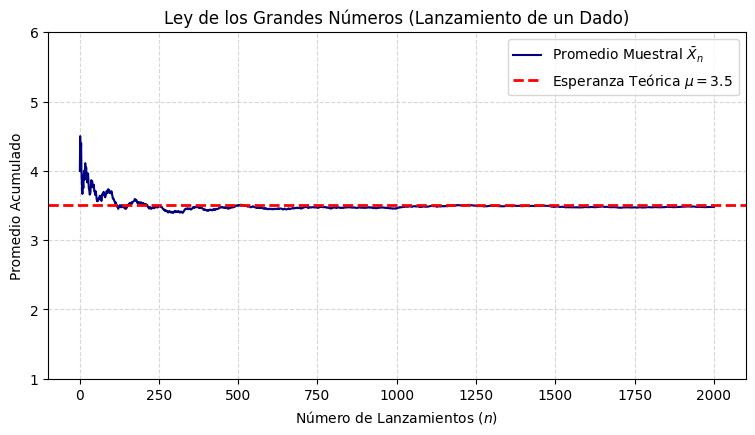

Promedio con 10 lanzamientos:   3.8000
Promedio con 100 lanzamientos:  3.6900
Promedio con 2000 lanzamientos: 3.4785


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros simples
n_lanzamientos = 2000
np.random.seed(42)

# 2. Simulación: lanzar un dado n veces
lanzamientos = np.random.randint(1, 7, size=n_lanzamientos)

# 3. Promedio acumulado paso a paso
pasos = np.arange(1, n_lanzamientos + 1)
promedio_acumulado = np.cumsum(lanzamientos) / pasos

# 4. Gráfica directa
plt.figure(figsize=(9, 4.5))
plt.plot(pasos, promedio_acumulado, color='navy', label='Promedio Muestral $\\bar{X}_n$')
plt.axhline(y=3.5, color='red', linestyle='--', linewidth=2, label='Esperanza Teórica $\\mu = 3.5$')

plt.title('Ley de los Grandes Números (Lanzamiento de un Dado)')
plt.xlabel('Número de Lanzamientos ($n$)')
plt.ylabel('Promedio Acumulado')
plt.ylim(1, 6)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 5. Imprimir resultados clave
print(f"Promedio con 10 lanzamientos:   {promedio_acumulado[9]:.4f}")
print(f"Promedio con 100 lanzamientos:  {promedio_acumulado[99]:.4f}")
print(f"Promedio con 2000 lanzamientos: {promedio_acumulado[-1]:.4f}")

## Teorema Central del Límite (TCL)

### Explicación e Idea Central
[cite_start]El **Teorema Central del Límite (TCL)** es uno de los resultados más sobresalientes e importantes de la teoría de la probabilidad y la inferencia estadística[cite: 18, 19].

[cite_start]Establece que, si tomamos muestras aleatorias independientes de tamaño $n$ de **cualquier población** (sin importar la forma de su distribución original, ya sea discreta, continua, sesgada o uniforme), la distribución de la **media muestral** $\bar{X}_n$ se aproximará a una **distribución normal** a medida que el tamaño de muestra $n$ sea suficientemente grande (típicamente $n \ge 30$)[cite: 18, 19].

#### Enunciado Formal:
Sean $X_1, X_2, \dots, X_n$ variables aleatorias independientes e idénticamente distribuidas (i.i.d.) con esperanza $\mathbb{E}[X_i] = \mu$ y varianza finita $\text{Var}(X_i) = \sigma^2 > 0$.

Definimos la media muestral como $\bar{X}_n = \frac{1}{n} \sum_{i=1}^{n} X_i$. A medida que $n \to \infty$, la variable estandarizada $Z_n$ converge en distribución a una Normal Estándar $\mathcal{N}(0, 1)$:

$$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)$$

Es decir, para $n$ suficientemente grande:

$$\bar{X}_n \approx \mathcal{N}\left( \mu, \frac{\sigma^2}{n} \right)$$

---

### Importancia Práctica en Inferencia
1. **Universalidad:** No necesitamos conocer la distribución exacta subyacente de los datos para hacer inferencias sobre su media.
2. **Construcción de Intervalos de Confianza y Pruebas de Hipótesis:** Permite justificar el uso de la prueba $z$ y la curva gaussiana para estimar parámetros poblacionales a partir de muestras grandes.

---

### Interpretación de la Simulación
* [cite_start]**Poblaciones no normales:** Incluso si los datos originales provienen de una distribución fuertemente sesgada (como la Exponencial) o plana (como la Uniforme), la suma/promedio de variables rompe ese sesgo[cite: 19].
* **Efecto del tamaño de muestra ($n$):**
  * Para $n = 1$ o $n = 2$, la distribución de las medias conserva la forma original de la población.
  * Conforme $n$ aumenta ($n = 10, 30, 100$), el histograma de las medias muestrales adopta rápidamente la forma característica de campana simétrica.
  * La dispersión (ancho de la campana) disminuye proporcionalmente a $\frac{\sigma}{\sqrt{n}}$.

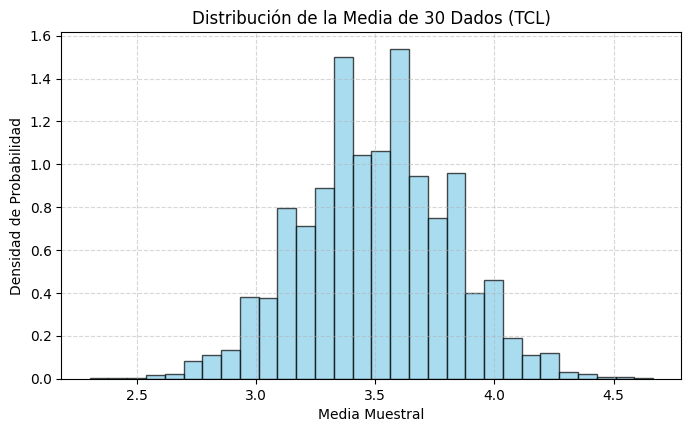

Media teórica del dado: 3.5
Media de nuestros promedios: 3.5008


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración sencilla
num_simulaciones = 10000  # Repetimos el experimento 10,000 veces
n_dados = 30             # Lanzamos 30 dados en cada experimento
np.random.seed(42)

# 2. Simulación: Generar matriz de lanzamientos (10000 experimentos x 30 dados)
dados = np.random.randint(1, 7, size=(num_simulaciones, n_dados))

# 3. Calcular el promedio de los 30 dados en cada experimento
medias_muestrales = np.mean(dados, axis=1)

# 4. Graficar el histograma de los promedios
plt.figure(figsize=(8, 4.5))
plt.hist(medias_muestrales, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7)

plt.title(f'Distribución de la Media de {n_dados} Dados (TCL)')
plt.xlabel('Media Muestral')
plt.ylabel('Densidad de Probabilidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. Imprimir la media y varianza observada vs teórica
media_teorica = 3.5
print(f"Media teórica del dado: {media_teorica}")
print(f"Media de nuestros promedios: {np.mean(medias_muestrales):.4f}")